# POLYHAQ — Feature-space Expansion Using Quantum Walks

This notebook provides a leakage-safe experimental scaffold for the Breast Cancer Wisconsin dataset. The validated 1D Quantum Walk physics and the supplied 2D Quantum Walk implementation are integrated behind independent execution switches.


# 1. Experiment Configuration


In [1]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
PRIMARY_METRIC = "f1_macro"
ALPHA = 0.05
EPSILON = 1e-8

T_VALUES_1D = list([1,3,5,7,9])
T_VALUES_2D = list([1,5,10])
T_SCREEN_VALUES_2D = [T_VALUES_2D[0], T_VALUES_2D[len(T_VALUES_2D) // 2], T_VALUES_2D[-1]]

N_SPLITS = 3
N_MAPPING_SCREEN_2D = 50
TOP_K_MAPPING_2D = 5
EXHAUSTIVE_2D_FULL_SEARCH = False
RUN_QW_1D_EXPERIMENTS = True   # The validated 1D runner is integrated below.
RUN_QW_2D_EXPERIMENTS = True   # The supplied 2D runner is integrated below.

# Reference convention implemented by the supplied runner: it still receives
# all ten encoded parameters, but use_mu_chi=False replaces mu/chi with the
# fixed values below, yielding the separable product-state branch.
MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}


The ML classifier is intentionally simple and fixed. The objective is to evaluate feature expansion—not classifier complexity. All feature, mapping, and $T$ choices must use cross-validation inside the training partition; the Test set is reserved for one final, unbiased evaluation.


# 2. Imports


In [2]:
import itertools
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, spearmanr, wilcoxon
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


# 3. Dataset Loading


In [3]:
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")
target_names = dict(enumerate(dataset.target_names))

print(f"Samples: {X.shape[0]} | Features: {X.shape[1]}")
print("Targets:", target_names)


Samples: 569 | Features: 30
Targets: {0: np.str_('malignant'), 1: np.str_('benign')}


# 4. Dataset Audit


In [4]:
audit = pd.DataFrame(
    {
        "dtype": X.dtypes.astype(str),
        "missing": X.isna().sum(),
        "unique": X.nunique(),
        "mean": X.mean(),
        "std": X.std(),
    }
)

class_balance = y.value_counts().sort_index().rename(index=target_names).to_frame("count")
class_balance["proportion"] = class_balance["count"] / len(y)

display(class_balance)
display(audit.head())
assert not X.isna().any().any(), "Unexpected missing feature values."
assert not y.isna().any(), "Unexpected missing targets."


,count,proportion
target,,
malignant,212,0.372583
benign,357,0.627417


,dtype,missing,unique,mean,std
mean radius,float64,0,456,14.127292,3.524049
mean texture,float64,0,479,19.289649,4.301036
mean perimeter,float64,0,522,91.969033,24.298981
mean area,float64,0,539,654.889104,351.914129
mean smoothness,float64,0,474,0.096360,0.014064


# 5. Train/Test Split

Exactly one stratified 80/20 split is created. There is no separate holdout validation split: validation is performed exclusively with stratified folds inside `X_train` and `y_train`.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)


def make_stratified_cv():
    """Return a fresh, reproducible five-fold training-only CV splitter."""
    return StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

print("Training partition:", X_train.shape)
print("Reserved test partition:", X_test.shape)
print("Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE")


Training partition: (455, 30)
Reserved test partition: (114, 30)
Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE


# 6. Feature Selection

The 4-feature and 10-feature views match the 1D and 2D parameter counts. Mutual-information selectors are fitted on training data only. Any performance-based choice involving features must be made inside training folds.


In [6]:
def select_features_mi(X_train, y_train, X_eval, k):
    """Fit SelectKBest on training data and transform train/evaluation matrices."""
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a DataFrame so feature names are preserved.")
    if not 1 <= k <= X_train.shape[1]:
        raise ValueError("k must be between 1 and the number of input features.")

    score_func = lambda values, labels: mutual_info_classif(
        values,
        labels,
        random_state=RANDOM_STATE,
    )
    selector = SelectKBest(score_func=score_func, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_eval_selected = selector.transform(X_eval)
    selected_indices = selector.get_support(indices=True)
    selected_feature_names = X_train.columns[selected_indices].tolist()
    mi_scores = selector.scores_[selected_indices]

    return {
        "selector": selector,
        "selected_indices": selected_indices,
        "selected_feature_names": selected_feature_names,
        "mi_scores": mi_scores,
        "X_train": X_train_selected,
        "X_eval": X_eval_selected,
        # Compatibility aliases used by the later experiment scaffold.
        "indices": selected_indices,
        "names": selected_feature_names,
        "scores": mi_scores,
    }


def ranked_mi_table(selection):
    table = pd.DataFrame(
        {
            "feature": selection["selected_feature_names"],
            "mutual_information_score": selection["mi_scores"],
        }
    ).sort_values("mutual_information_score", ascending=False, ignore_index=True)
    table.insert(0, "rank", np.arange(1, len(table) + 1))
    return table


# The evaluation matrix is training data here; the reserved test set is untouched.
features_1d = select_features_mi(X_train, y_train, X_train, k=4)
features_2d = select_features_mi(X_train, y_train, X_train, k=10)

features_1d_table = ranked_mi_table(features_1d)
features_2d_table = ranked_mi_table(features_2d)

print("1D selection (k=4)")
display(features_1d_table)
print("2D selection (k=10)")
display(features_2d_table)


1D selection (k=4)


,rank,feature,mutual_information_score
0,1,worst perimeter,0.471238
1,2,worst area,0.461952
2,3,worst radius,0.458392
3,4,mean concave points,0.443749


2D selection (k=10)


,rank,feature,mutual_information_score
0,1,worst perimeter,0.471238
1,2,worst area,0.461952
2,3,worst radius,0.458392
3,4,mean concave points,0.443749
4,5,worst concave points,0.442864
5,6,mean perimeter,0.411013
6,7,mean radius,0.364736
7,8,mean area,0.357780
8,9,mean concavity,0.353144
9,10,area error,0.337466


# 7. Classical Baselines

Both baselines use the exact same fixed `StandardScaler` + `LogisticRegression` architecture. The polynomial baseline changes only the feature space. Reported baseline-summary values are means from five training-only stratified folds; the Test set remains reserved for Section 17.


In [7]:
METRIC_COLUMNS = [
    "accuracy",
    "f1_macro",
    "f1_malignant",
    "precision_malignant",
    "recall_malignant",
]


def evaluate_classifier(X_train, X_eval, y_train, y_eval):
    """Fit the fixed classifier and evaluate it on one supplied evaluation set."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    model = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_eval_scaled)

    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "f1_macro": f1_score(y_eval, predictions, average="macro"),
        "f1_malignant": f1_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "precision_malignant": precision_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "recall_malignant": recall_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "predictions": predictions,
        "scaler": scaler,
        "model": model,
    }


def _take_rows(values, indices):
    return values.iloc[indices] if hasattr(values, "iloc") else np.asarray(values)[indices]


def evaluate_feature_space_cv(X_values, y_values, transformer=None):
    """Generate fold-local transformations and out-of-fold baseline metrics."""
    fold_records = []
    out_of_fold_predictions = np.empty(len(y_values), dtype=int)

    for fold, (fit_indices, eval_indices) in enumerate(
        make_stratified_cv().split(X_values, y_values), start=1
    ):
        X_fit = _take_rows(X_values, fit_indices)
        X_eval = _take_rows(X_values, eval_indices)
        y_fit = _take_rows(y_values, fit_indices)
        y_eval = _take_rows(y_values, eval_indices)

        if transformer is not None:
            fold_transformer = clone(transformer)
            X_fit = fold_transformer.fit_transform(X_fit)
            X_eval = fold_transformer.transform(X_eval)

        result = evaluate_classifier(X_fit, X_eval, y_fit, y_eval)
        fold_records.append({"fold": fold, **{key: result[key] for key in METRIC_COLUMNS}})
        out_of_fold_predictions[eval_indices] = result["predictions"]

    return {
        "fold_scores": pd.DataFrame(fold_records),
        "predictions": out_of_fold_predictions,
    }


# No classifier hyperparameters are tuned for either baseline.
polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
original_cv_result = evaluate_feature_space_cv(X_train, y_train)
polynomial_cv_result = evaluate_feature_space_cv(
    X_train,
    y_train,
    transformer=polynomial_transformer,
)

original_cv_scores = original_cv_result["fold_scores"]
polynomial_cv_scores = polynomial_cv_result["fold_scores"]

# Fit a separate polynomial transformer on all training data for dimensions and later final use.
X_train_polynomial = polynomial_transformer.fit_transform(X_train)

baseline_summary = pd.DataFrame(
    [
        {
            "feature_space": "Original",
            "input_dimension": X_train.shape[1],
            **original_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
        {
            "feature_space": "Polynomial degree 2",
            "input_dimension": X_train_polynomial.shape[1],
            **polynomial_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
    ]
)

print("Training-only 5-fold CV baseline summary")
display(baseline_summary)

dimensions = pd.DataFrame(
    {
        "feature_space": [
            "Original features",
            "Polynomial features",
            "1D selected features",
            "2D selected features",
        ],
        "dimension": [
            X_train.shape[1],
            X_train_polynomial.shape[1],
            features_1d["X_train"].shape[1],
            features_2d["X_train"].shape[1],
        ],
    }
)
print("Feature-space dimensions")
display(dimensions)


Training-only 5-fold CV baseline summary


,feature_space,input_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant
0,Original,30,0.978022,0.976426,0.970308,0.976975,0.964706
1,Polynomial degree 2,495,0.964835,0.962275,0.952473,0.959446,0.947059


Feature-space dimensions


,feature_space,dimension
0,Original features,30
1,Polynomial features,495
2,1D selected features,4
3,2D selected features,10


# 8. Quantum Parameter Encoding

This section only scales selected classical inputs and maps them into declared parameter ranges. It does not simulate a Quantum Walk.

> **Implementation note:** These ranges are implementation assumptions and must be confirmed with the physics team.


In [8]:
PARAMS_1D = ["theta1", "phi1", "alpha1", "beta1"]
PARAM_RANGES_1D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
}

PARAMS_2D = [
    "theta1", "phi1", "alpha1", "beta1",
    "theta2", "phi2", "alpha2", "beta2", "mu", "chi",
]
PARAM_RANGES_2D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
    "theta2": (0, np.pi),
    "phi2": (0, 2 * np.pi),
    "alpha2": (0, np.pi),
    "beta2": (0, 2 * np.pi),
    "mu": (0, np.pi),
    "chi": (0, 2 * np.pi),
}


def map_unit_interval_to_range(x, low, high):
    return low + np.asarray(x) * (high - low)


def apply_feature_parameter_mapping(
    X_unit, feature_names, mapping, param_order, param_ranges
):
    """Map unit-scaled features to ranges, returning canonical parameter order."""
    X_unit = np.asarray(X_unit, dtype=float)
    feature_names = list(feature_names)
    param_order = list(param_order)

    if X_unit.ndim != 2 or X_unit.shape[1] != len(feature_names):
        raise ValueError("X_unit columns must match feature_names.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("feature_names must be unique.")
    if len(set(param_order)) != len(param_order):
        raise ValueError("param_order must contain unique parameters.")
    if not isinstance(mapping, dict):
        raise TypeError("mapping must be an explicit feature-to-parameter dictionary.")
    if set(mapping) != set(feature_names):
        raise ValueError("Mapping keys must match feature_names exactly.")
    if len(mapping.values()) != len(set(mapping.values())):
        raise ValueError("Each quantum parameter must be used exactly once.")
    if set(mapping.values()) != set(param_order):
        raise ValueError("Mapping values must match param_order exactly.")
    if not set(param_order).issubset(param_ranges):
        raise ValueError("A range is required for every quantum parameter.")
    if not np.all(np.isfinite(X_unit)):
        raise ValueError("X_unit must contain only finite values.")
    if np.any(X_unit < 0) or np.any(X_unit > 1):
        raise ValueError("X_unit values must lie in [0, 1].")

    feature_to_index = {name: index for index, name in enumerate(feature_names)}
    parameter_to_feature = {parameter: feature for feature, parameter in mapping.items()}
    encoded = np.empty((X_unit.shape[0], len(param_order)), dtype=float)
    for parameter_index, parameter in enumerate(param_order):
        feature_index = feature_to_index[parameter_to_feature[parameter]]
        low, high = param_ranges[parameter]
        if not np.isfinite(low) or not np.isfinite(high) or low > high:
            raise ValueError(f"Invalid range for {parameter!r}.")
        encoded[:, parameter_index] = map_unit_interval_to_range(
            X_unit[:, feature_index], low, high
        )
    return encoded


# These separate scalers are fitted only on the selected training features.
# Any later test transform must call transform(), never fit() or fit_transform().
minmax_1d = MinMaxScaler(feature_range=(0, 1), clip=True)
minmax_2d = MinMaxScaler(feature_range=(0, 1), clip=True)
X_train_1d_unit = minmax_1d.fit_transform(features_1d["X_train"])
X_train_2d_unit = minmax_2d.fit_transform(features_2d["X_train"])

identity_mapping_1d = dict(zip(features_1d["names"], PARAMS_1D))
identity_mapping_2d = dict(zip(features_2d["names"], PARAMS_2D))
X_train_params_1d = apply_feature_parameter_mapping(
    X_train_1d_unit, features_1d["names"], identity_mapping_1d,
    PARAMS_1D, PARAM_RANGES_1D,
)
X_train_params_2d = apply_feature_parameter_mapping(
    X_train_2d_unit, features_2d["names"], identity_mapping_2d,
    PARAMS_2D, PARAM_RANGES_2D,
)

print("Encoded training shapes:", X_train_params_1d.shape, X_train_params_2d.shape)


Encoded training shapes: (455, 4) (455, 10)


# 9. Feature-to-Parameter Mapping

Mappings assign selected feature columns to canonical Quantum Walk parameters. Candidate mappings are configuration choices and therefore must be compared using training-only cross-validation.


In [9]:
def iter_exhaustive_mappings(feature_names, quantum_params):
    """Yield explicit mapping records lazily in deterministic order."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    if len(feature_names) != len(quantum_params):
        raise ValueError("Features and parameters must have equal lengths.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("Feature names must be unique.")
    if len(set(quantum_params)) != len(quantum_params):
        raise ValueError("Quantum parameter names must be unique.")
    for mapping_id, permutation in enumerate(itertools.permutations(quantum_params)):
        yield {
            "mapping_id": mapping_id,
            "mapping": dict(zip(feature_names, permutation)),
        }


def sample_random_mappings(
    feature_names, quantum_params, n_mappings, random_state
):
    """Sample unique explicit mappings reproducibly without enumerating n!."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    if len(feature_names) != len(quantum_params):
        raise ValueError("Features and parameters must have equal lengths.")
    if len(set(feature_names)) != len(feature_names):
        raise ValueError("Feature names must be unique.")
    if len(set(quantum_params)) != len(quantum_params):
        raise ValueError("Quantum parameter names must be unique.")
    if not isinstance(n_mappings, (int, np.integer)) or n_mappings < 0:
        raise ValueError("n_mappings must be a non-negative integer.")
    if n_mappings > math.factorial(len(quantum_params)):
        raise ValueError("n_mappings exceeds the number of unique mappings.")

    rng = np.random.default_rng(random_state)
    seen = set()
    sampled = []
    while len(sampled) < n_mappings:
        permutation = tuple(rng.permutation(quantum_params).tolist())
        if permutation in seen:
            continue
        seen.add(permutation)
        sampled.append(
            {
                "mapping_id": f"random_{len(sampled):06d}",
                "mapping": dict(zip(feature_names, permutation)),
            }
        )
    return sampled


# 4! is small, so the complete 1D search space is intentionally materialized.
mappings_1d = list(iter_exhaustive_mappings(features_1d["names"], PARAMS_1D))

# 10! is large: retain a lazy exhaustive iterator factory and a staged-search sample.
mappings_2d_exhaustive = lambda: iter_exhaustive_mappings(
    features_2d["names"], PARAMS_2D
)
example_random_mappings_2d = sample_random_mappings(
    features_2d["names"], PARAMS_2D, n_mappings=3, random_state=RANDOM_STATE
)

# Sanity tests for cardinality, bijections, canonical ordering, distinctness, and bounds.
mapping_signatures_1d = {
    tuple(record["mapping"][feature] for feature in features_1d["names"])
    for record in mappings_1d
}
assert len(mappings_1d) == math.factorial(4) == 24
assert len(mapping_signatures_1d) == 24
for record in mappings_1d:
    mapping = record["mapping"]
    assert set(mapping) == set(features_1d["names"])
    assert len(mapping) == len(set(mapping)) == 4
    assert set(mapping.values()) == set(PARAMS_1D)
    assert len(mapping.values()) == len(set(mapping.values())) == 4

sanity_unit = np.array([[0.10, 0.35, 0.60, 0.90]])
sanity_features = ["feature_A", "feature_B", "feature_C", "feature_D"]
sanity_mapping_a = dict(zip(sanity_features, PARAMS_1D))
sanity_mapping_b = {**sanity_mapping_a, "feature_A": "beta1", "feature_D": "theta1"}
sanity_encoded_a = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_a, PARAMS_1D, PARAM_RANGES_1D
)
sanity_encoded_b = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_b, PARAMS_1D, PARAM_RANGES_1D
)
np.testing.assert_allclose(
    sanity_encoded_b[0],
    [0.90 * np.pi, 0.35 * 2 * np.pi, 0.60 * np.pi, 0.10 * 2 * np.pi],
)
assert not np.allclose(sanity_encoded_a, sanity_encoded_b)

encoded_matrices_1d = {}
for record in mappings_1d:
    encoded = apply_feature_parameter_mapping(
        X_train_1d_unit, features_1d["names"], record["mapping"],
        PARAMS_1D, PARAM_RANGES_1D,
    )
    encoded_matrices_1d[record["mapping_id"]] = encoded
    for column, parameter in enumerate(PARAMS_1D):
        low, high = PARAM_RANGES_1D[parameter]
        assert np.all((encoded[:, column] >= low) & (encoded[:, column] <= high))
assert not np.allclose(encoded_matrices_1d[0], encoded_matrices_1d[1])
for column, parameter in enumerate(PARAMS_2D):
    low, high = PARAM_RANGES_2D[parameter]
    assert np.all(
        (X_train_params_2d[:, column] >= low)
        & (X_train_params_2d[:, column] <= high)
    )

assert len({
    tuple(record["mapping"][feature] for feature in features_2d["names"])
    for record in example_random_mappings_2d
}) == len(example_random_mappings_2d)
assert example_random_mappings_2d == sample_random_mappings(
    features_2d["names"], PARAMS_2D, 3, RANDOM_STATE
)
for record in example_random_mappings_2d:
    assert set(record["mapping"]) == set(features_2d["names"])
    assert set(record["mapping"].values()) == set(PARAMS_2D)
    encoded = apply_feature_parameter_mapping(
        X_train_2d_unit, features_2d["names"], record["mapping"],
        PARAMS_2D, PARAM_RANGES_2D,
    )
    for column, parameter in enumerate(PARAMS_2D):
        low, high = PARAM_RANGES_2D[parameter]
        assert np.all((encoded[:, column] >= low) & (encoded[:, column] <= high))

selected_features_1d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 5), "selected_1d_feature": features_1d["names"]}
)
selected_features_2d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 11), "selected_2d_feature": features_2d["names"]}
)
example_mapping_rows = []
for dimension, record in [("1D", mappings_1d[0]), ("2D", example_random_mappings_2d[0])]:
    for feature, parameter in record["mapping"].items():
        example_mapping_rows.append(
            {"dimension": dimension, "mapping_id": record["mapping_id"],
             "selected_feature": feature, "quantum_parameter": parameter}
        )
example_feature_parameter_mappings_df = pd.DataFrame(example_mapping_rows)

print(f"1D mapping candidates: {len(mappings_1d)}")
print(f"2D exhaustive search remains lazy ({math.factorial(10):,} candidates).")
print("All encoding sanity tests passed.")
display(selected_features_1d_df)
display(selected_features_2d_df)
display(example_feature_parameter_mappings_df)


1D mapping candidates: 24
2D exhaustive search remains lazy (3,628,800 candidates).
All encoding sanity tests passed.


,feature_position,selected_1d_feature
0,1,mean concave points
1,2,worst radius
2,3,worst perimeter
3,4,worst area


,feature_position,selected_2d_feature
0,1,mean radius
1,2,mean perimeter
2,3,mean area
3,4,mean concavity
4,5,mean concave points
5,6,area error
6,7,worst radius
7,8,worst perimeter
8,9,worst area
9,10,worst concave points


,dimension,mapping_id,selected_feature,quantum_parameter
0,1D,0,mean concave points,theta1
1,1D,0,worst radius,phi1
2,1D,0,worst perimeter,alpha1
3,1D,0,worst area,beta1
4,2D,random_000000,mean radius,phi2
5,2D,random_000000,mean perimeter,alpha2
6,2D,random_000000,mean area,theta1
7,2D,random_000000,mean concavity,beta2
8,2D,random_000000,mean concave points,beta1
9,2D,random_000000,area error,alpha1


## 9.1 Classical Correlation and Future Entanglement Analysis

This subsection keeps the challenge question split into three independently auditable parts.

### Classical contribution: feature correlation

Using `X_train` only, calculate the absolute Pearson correlation among the ten selected 2D classical features. Each feature's `mean_absolute_correlation` is its average absolute correlation with the other nine features; diagonal self-correlation is excluded. This is a classical-data statistic and is not an entanglement measure.

### Physics contribution: parameter influence on entanglement

The physics team must supply a defensible sensitivity score for how each QW parameter influences an agreed entanglement measure. `parameter_entanglement_scores` is intentionally initialized to `NaN`; this notebook does not define, simulate, or infer those physics scores.

### Joint contribution: test after mapping selection

Only after training-only optimization identifies the best 2D feature-to-parameter mapping can classical feature-correlation scores be paired with parameter entanglement-sensitivity scores. `combine_feature_correlation_with_entanglement` prepares that table, and `compute_feature_entanglement_spearman` can compute a rank correlation when at least three finite paired scores exist.

The joint correlation is deliberately **not executed or interpreted** here. It must remain unset until the physics team supplies a defensible entanglement-sensitivity measure and the best 2D mapping has been selected without Test-set information.


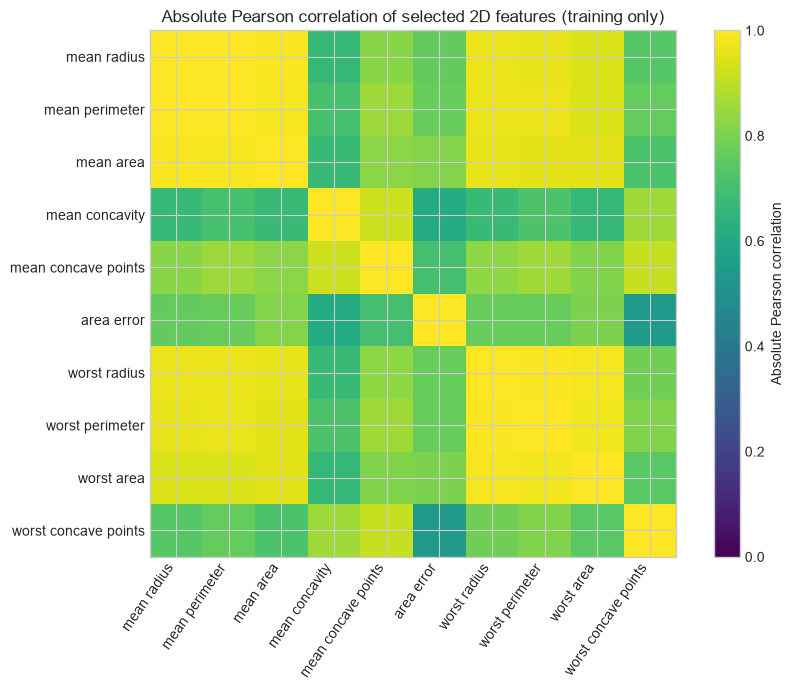

,feature,MI_score,mean_absolute_correlation
0,worst perimeter,0.471238,0.902520
1,mean perimeter,0.411013,0.895968
2,worst radius,0.458392,0.893670
3,mean area,0.357780,0.888940
4,mean radius,0.364736,0.885132
5,worst area,0.461952,0.883212
6,mean concave points,0.443749,0.853648
7,worst concave points,0.442864,0.785863
8,area error,0.337466,0.753275
9,mean concavity,0.353144,0.751324


Joint feature/entanglement analysis not executed: physics-team parameter sensitivities and the best training-selected 2D mapping are required.


In [10]:
selected_2d_training_df = X_train.loc[:, features_2d["names"]].copy()
absolute_pearson_correlation_2d = selected_2d_training_df.corr(
    method="pearson"
).abs()

if absolute_pearson_correlation_2d.shape != (len(PARAMS_2D), len(PARAMS_2D)):
    raise ValueError("The 2D correlation matrix must contain ten selected features.")
if not np.all(np.isfinite(absolute_pearson_correlation_2d.to_numpy())):
    raise ValueError(
        "Pearson correlations are undefined; check selected training features "
        "for constant or non-finite values."
    )

# Exclude each feature's self-correlation from its row average.
off_diagonal_correlations = absolute_pearson_correlation_2d.copy()
off_diagonal_correlations = pd.DataFrame(
    np.array(off_diagonal_correlations, dtype=float, copy=True),
    index=off_diagonal_correlations.index,
    columns=off_diagonal_correlations.columns,
)
# np.fill_diagonal(off_diagonal_correlation?zs.values, np.nan)
mean_absolute_correlation = off_diagonal_correlations.mean(axis=1, skipna=True)

mi_score_by_feature = dict(
    zip(features_2d["selected_feature_names"], features_2d["mi_scores"])
)
feature_correlation_summary_df = pd.DataFrame(
    {
        "feature": features_2d["selected_feature_names"],
        "MI_score": [
            float(mi_score_by_feature[name])
            for name in features_2d["selected_feature_names"]
        ],
        "mean_absolute_correlation": [
            float(mean_absolute_correlation.loc[name])
            for name in features_2d["selected_feature_names"]
        ],
    }
).sort_values(
    "mean_absolute_correlation",
    ascending=False,
    ignore_index=True,
)


fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(
    absolute_pearson_correlation_2d.to_numpy(),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    aspect="equal",
)
tick_positions = np.arange(len(absolute_pearson_correlation_2d))
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(
    absolute_pearson_correlation_2d.columns,
    rotation=55,
    ha="right",
)
ax.set_yticklabels(absolute_pearson_correlation_2d.index)
ax.set_title("Absolute Pearson correlation of selected 2D features (training only)")
fig.colorbar(heatmap, ax=ax, label="Absolute Pearson correlation")
fig.tight_layout()
plt.show()


# Physics-team placeholder only. NaN means no defensible sensitivity was supplied.
parameter_entanglement_scores = {
    "theta1": np.nan,
    "phi1": np.nan,
    "alpha1": np.nan,
    "beta1": np.nan,
    "theta2": np.nan,
    "phi2": np.nan,
    "alpha2": np.nan,
    "beta2": np.nan,
    "mu": np.nan,
    "chi": np.nan,
}


def combine_feature_correlation_with_entanglement(
    best_2d_mapping,
    entanglement_scores,
    correlation_summary=feature_correlation_summary_df,
):
    """Join classical scores to physics scores through a selected 2D mapping."""
    if hasattr(best_2d_mapping, "to_dict"):
        best_2d_mapping = best_2d_mapping.to_dict()
    if isinstance(best_2d_mapping, dict) and isinstance(
        best_2d_mapping.get("mapping"), dict
    ):
        best_2d_mapping = dict(best_2d_mapping["mapping"])
    if not isinstance(best_2d_mapping, dict):
        raise TypeError("best_2d_mapping must be a feature-to-parameter dictionary.")
    if not isinstance(entanglement_scores, dict):
        raise TypeError("entanglement_scores must be a parameter-to-score dictionary.")

    expected_features = set(correlation_summary["feature"])
    if set(best_2d_mapping) != expected_features:
        raise ValueError(
            "best_2d_mapping keys must match the ten selected 2D features."
        )
    if set(best_2d_mapping.values()) != set(PARAMS_2D):
        raise ValueError("best_2d_mapping must use every 2D parameter exactly once.")
    if not set(PARAMS_2D).issubset(entanglement_scores):
        raise ValueError("An entanglement-score placeholder is required per parameter.")

    joined = correlation_summary.loc[
        :, ["feature", "mean_absolute_correlation"]
    ].rename(
        columns={
            "mean_absolute_correlation": "feature_correlation_score",
        }
    )
    joined["mapped_parameter"] = joined["feature"].map(best_2d_mapping)
    joined["parameter_entanglement_score"] = joined["mapped_parameter"].map(
        entanglement_scores
    )
    return joined[
        [
            "feature",
            "mapped_parameter",
            "feature_correlation_score",
            "parameter_entanglement_score",
        ]
    ]


def compute_feature_entanglement_spearman(
    combined_scores,
    minimum_valid_pairs=3,
):
    """Compute Spearman rho only when enough finite physics scores are present."""
    required_columns = {
        "feature_correlation_score",
        "parameter_entanglement_score",
    }
    if not required_columns.issubset(combined_scores.columns):
        raise ValueError(f"combined_scores must contain {sorted(required_columns)}.")
    if minimum_valid_pairs < 3:
        raise ValueError("minimum_valid_pairs must be at least 3.")

    classical = pd.to_numeric(
        combined_scores["feature_correlation_score"], errors="coerce"
    ).to_numpy(dtype=float)
    physics = pd.to_numeric(
        combined_scores["parameter_entanglement_score"], errors="coerce"
    ).to_numpy(dtype=float)
    valid = np.isfinite(classical) & np.isfinite(physics)
    n_valid = int(valid.sum())
    if n_valid < minimum_valid_pairs:
        return {
            "spearman_rho": np.nan,
            "p_value": np.nan,
            "n_valid": n_valid,
            "status": "not computed: insufficient finite paired scores",
        }

    rho, p_value = spearmanr(classical[valid], physics[valid])
    if not np.isfinite(rho):
        return {
            "spearman_rho": np.nan,
            "p_value": np.nan,
            "n_valid": n_valid,
            "status": "not computed: rank correlation is undefined",
        }
    return {
        "spearman_rho": float(rho),
        "p_value": float(p_value),
        "n_valid": n_valid,
        "status": "computed",
    }


# Deliberately remain unset until both prerequisites exist.
best_2d_feature_entanglement_df = None
feature_entanglement_spearman_result = None

assert feature_correlation_summary_df.shape == (10, 3)
assert feature_correlation_summary_df.columns.tolist() == [
    "feature",
    "MI_score",
    "mean_absolute_correlation",
]
assert feature_correlation_summary_df[
    "mean_absolute_correlation"
].is_monotonic_decreasing
assert set(parameter_entanglement_scores) == set(PARAMS_2D)

display(feature_correlation_summary_df)
print(
    "Joint feature/entanglement analysis not executed: physics-team parameter "
    "sensitivities and the best training-selected 2D mapping are required."
)


# 10. Physics Team Integration Contract

The two interface functions below are the boundary between the AI pipeline and the Quantum Walk implementations. The 1D runner and the supplied 2D coin, evolution, entanglement, and lattice construction are integrated here.

The **physics team** is responsible for:

- initial quantum state construction;
- Coin operator;
- Shift operator;
- 1D QW evolution;
- 2D QW evolution;
- correct implementation of `mu` and `chi`;
- correct complex quantum amplitudes;
- physical correctness and normalization.

The **AI pipeline** is responsible for:

- classical feature selection;
- scaling;
- feature-to-parameter mapping;
- QW-derived feature extraction;
- mapping/`T` search;
- ML evaluation;
- statistical comparison.


In [11]:
PROBABILITY_ATOL = 1e-8
NEGATIVE_PROBABILITY_ATOL = 1e-12


def move(space):
    """Move the walker one step: coin |0> keeps its index, coin |1> advances by two."""
    new_space = np.zeros([len(space) + 2, 2], dtype=complex)
    for i in range(len(space)):
        new_space[i][0] = space[i][0]
        new_space[i + 2][1] = space[i][1]
    return new_space


def create_coin_operator(alpha, beta):
    """Create the 2x2 coin operator C(alpha, beta)."""
    return np.array([
        [np.cos(alpha) * np.exp(1j * beta), np.sin(alpha)],
        [-np.sin(alpha), np.cos(alpha) * np.exp(-1j * beta)]
    ], dtype=complex)


def run_qw_1d(theta, phi, alpha, beta, num_steps):
    """Run a single 1D quantum walk and return its position probabilities."""
    coin = create_coin_operator(alpha, beta)
    state = np.array([
        [np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)]
    ], dtype=complex)

    for _ in range(num_steps):
        for i in range(len(state)):
            state[i] = coin @ state[i]
        state = move(state)

    return (np.abs(state) ** 2).sum(axis=1)


def _check_params(params, required, ranges, atol=1e-9):
    missing = [key for key in required if key not in params]
    if missing:
        raise KeyError(f"params is missing required keys: {missing}")
    out_of_range = []
    for key in required:
        low, high = ranges[key]
        value = float(params[key])
        if not (low - atol <= value <= high + atol):
            out_of_range.append(
                f"{key}={value:.6g} not in [{low:.6g}, {high:.6g}]"
            )
    if out_of_range:
        raise ValueError(
            "params outside declared ranges: " + "; ".join(out_of_range)
        )


def quantum_walk_1d(params, T):
    """Run the validated 1D walk through the physics handoff contract."""
    _check_params(params, PARAMS_1D, PARAM_RANGES_1D)
    if not isinstance(T, (int, np.integer)) or T < 0:
        raise ValueError(f"T must be a non-negative integer, got {T}")
    probabilities = run_qw_1d(
        params["theta1"], params["phi1"],
        params["alpha1"], params["beta1"], int(T),
    )
    positions = np.arange(-T, T + 1, dtype=float)
    return {"positions": positions, "probabilities": probabilities}

def _initial_coin_state(theta, phi):
    """Return the supplied single-qubit initial coin state."""
    return np.array([
        np.cos(theta / 2),
        np.sin(theta / 2) * np.exp(1j * phi),
    ], dtype=complex)


def _orthogonal_coin_state(theta, phi):
    """Return the normalized state orthogonal to _initial_coin_state."""
    return np.array([
        np.sin(theta / 2),
        -np.cos(theta / 2) * np.exp(1j * phi),
    ], dtype=complex)


def _evolve_1d_amplitudes(initial_state, coin, num_steps):
    """Apply the supplied coin-and-move evolution without measuring."""
    state = np.asarray(initial_state, dtype=complex).reshape(1, 2)
    for _ in range(num_steps):
        for position_index in range(len(state)):
            state[position_index] = coin @ state[position_index]
        state = move(state)
    return state


def _entangle_2d_branches(mu, chi, state1, state1_orthogonal,
                           state2, state2_orthogonal):
    """Combine the two orthogonal product branches from the supplied walk."""
    return (
        np.cos(mu / 2) * np.kron(state1, state2)
        + np.exp(1j * chi) * np.sin(mu / 2)
        * np.kron(state1_orthogonal, state2_orthogonal)
    )


def quantum_walk_2d(params, T, use_mu_chi=True):
    """Run the supplied separable/entangled 2D quantum walk.

    The first coin drives x and the second drives y. Each lattice point has
    four joint-coin amplitudes ordered by np.kron. Setting use_mu_chi=False
    forces the reference state mu=chi=0 while still accepting all ten keys.
    """
    _check_params(params, PARAMS_2D, PARAM_RANGES_2D)
    if not isinstance(T, (int, np.integer)) or T < 0:
        raise ValueError(f"T must be a non-negative integer, got {T}")
    if not isinstance(use_mu_chi, (bool, np.bool_)):
        raise TypeError("use_mu_chi must be a boolean.")

    coin1 = create_coin_operator(params["alpha1"], params["beta1"])
    coin2 = create_coin_operator(params["alpha2"], params["beta2"])
    initial1 = _initial_coin_state(params["theta1"], params["phi1"])
    initial2 = _initial_coin_state(params["theta2"], params["phi2"])
    orthogonal1 = _orthogonal_coin_state(params["theta1"], params["phi1"])
    orthogonal2 = _orthogonal_coin_state(params["theta2"], params["phi2"])

    state1 = _evolve_1d_amplitudes(initial1, coin1, int(T))
    state2 = _evolve_1d_amplitudes(initial2, coin2, int(T))
    state1_orthogonal = _evolve_1d_amplitudes(orthogonal1, coin1, int(T))
    state2_orthogonal = _evolve_1d_amplitudes(orthogonal2, coin2, int(T))

    mu = params["mu"] if use_mu_chi else MU_CHI_REFERENCE["mu"]
    chi = params["chi"] if use_mu_chi else MU_CHI_REFERENCE["chi"]
    final_state = _entangle_2d_branches(
        mu, chi, state1, state1_orthogonal, state2, state2_orthogonal
    )

    lattice = np.arange(-T, T + 1, dtype=float)
    x_grid, y_grid = np.meshgrid(lattice, lattice, indexing="ij")
    positions = np.column_stack((x_grid.ravel(), y_grid.ravel()))
    probabilities = np.sum(np.abs(final_state) ** 2, axis=1).real
    return {
        "positions": positions,
        "probabilities": probabilities,
        "state": final_state,
    }


quantum_walk_1d._is_physics_stub = False
quantum_walk_2d._is_physics_stub = False


def validate_quantum_walk_callable(walk, expected_parameter_count):
    if not callable(walk):
        raise TypeError("The external Quantum Walk implementation must be callable.")
    if expected_parameter_count not in (len(PARAMS_1D), len(PARAMS_2D)):
        raise ValueError("Expected parameter count must be 4 (1D) or 10 (2D).")


def _require_finite_array(values, name):
    array = np.asarray(values)
    if array.size == 0:
        raise ValueError(f"{name} must not be empty.")
    try:
        is_finite = np.isfinite(array)
    except TypeError as exc:
        raise TypeError(f"{name} must be a numeric array.") from exc
    if not np.all(is_finite):
        raise ValueError(f"{name} contains NaN or infinite values.")
    return array


def validate_quantum_walk_output(output, spatial_dimensions):
    """Validate and normalize a physics-team QW result dictionary."""
    if not isinstance(output, dict):
        raise TypeError("Quantum Walk output must be a dictionary.")
    missing = {"positions", "probabilities"} - set(output)
    if missing:
        raise ValueError(f"Quantum Walk output is missing: {sorted(missing)}")
    if spatial_dimensions not in (1, 2):
        raise ValueError("spatial_dimensions must be 1 or 2.")

    if not isinstance(output["positions"], np.ndarray):
        raise TypeError("positions must be a NumPy array.")
    if not isinstance(output["probabilities"], np.ndarray):
        raise TypeError("probabilities must be a NumPy array.")
    positions = _require_finite_array(output["positions"], "positions")
    probabilities = _require_finite_array(
        output["probabilities"], "probabilities"
    )
    if np.iscomplexobj(positions):
        raise TypeError("positions must contain real coordinates.")
    if np.iscomplexobj(probabilities):
        raise TypeError("probabilities must be real-valued.")
    probabilities = probabilities.astype(float, copy=False)
    if probabilities.ndim != 1:
        raise ValueError("probabilities must be a one-dimensional array.")
    if spatial_dimensions == 1 and positions.ndim != 1:
        raise ValueError("1D positions must be a one-dimensional array.")
    if spatial_dimensions == 2 and (positions.ndim != 2 or positions.shape[1] != 2):
        raise ValueError("2D positions must have shape (N, 2) with [x, y] rows.")
    if positions.shape[0] != probabilities.size:
        raise ValueError("positions and probabilities must have compatible lengths.")
    if np.any(probabilities < -NEGATIVE_PROBABILITY_ATOL):
        raise ValueError("probabilities contain materially negative values.")
    if not np.isclose(probabilities.sum(), 1.0, atol=PROBABILITY_ATOL, rtol=0.0):
        raise ValueError("probabilities must sum approximately to 1.")

    # Clip only round-off-scale negative values, then restore exact normalization.
    probabilities = np.clip(probabilities, 0.0, None)
    probabilities = probabilities / probabilities.sum()

    validated = dict(output)
    validated["positions"] = positions
    validated["probabilities"] = probabilities
    for optional_name in ("position_amplitudes", "state"):
        if optional_name in output and output[optional_name] is not None:
            if not isinstance(output[optional_name], np.ndarray):
                raise TypeError(f"{optional_name} must be a NumPy array.")
            optional_array = _require_finite_array(output[optional_name], optional_name)
            if not np.iscomplexobj(optional_array):
                raise TypeError(f"{optional_name} must contain complex amplitudes.")
            if optional_name == "position_amplitudes" and (
                optional_array.ndim == 0 or optional_array.shape[0] != probabilities.size
            ):
                raise ValueError(
                    "position_amplitudes and probabilities must have compatible lengths."
                )
            validated[optional_name] = optional_array
    return validated


def validate_quantum_walk_1d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=1)


def validate_quantum_walk_2d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=2)


print("Validated 1D runner, supplied 2D runner, and output validators are defined.")


Validated 1D runner, supplied 2D runner, and output validators are defined.


# 11. Quantum-Walk-derived Feature Extraction

These reusable extractors summarize a validated output distribution; they do **not** perform Quantum Walk evolution. For 1D outputs, `mean` is exactly the measurement expectation $\langle x\rangle$, so it is stored once rather than duplicated. `expectation_x2` stores $\langle x^2\rangle$.

The distribution statistics use probability-weighted central moments. `kurtosis` is Pearson kurtosis (not excess kurtosis), `shannon_entropy` uses the natural logarithm, `localization` is the inverse participation ratio $\sum_i p_i^2$, and `spread` is the standard deviation. In 2D, `spread` is $\sqrt{\mathrm{Var}(x)+\mathrm{Var}(y)}$ and `radial_spread` is the standard deviation of $r=\sqrt{x^2+y^2}$.

The optional interference statistic is computed only from one complex amplitude per position.

> **TODO:** The physics team must confirm how coin/internal-state amplitudes are reduced to one complex amplitude per position.


In [12]:
from collections import OrderedDict


QW_FEATURES_1D = (
    "mean",
    "variance",
    "skewness",
    "kurtosis",
    "shannon_entropy",
    "localization",
    "spread",
    "expectation_x2",
)
QW_FEATURES_2D = (
    "mean_x",
    "mean_y",
    "variance_x",
    "variance_y",
    "covariance_xy",
    "radial_spread",
    "shannon_entropy",
    "localization",
    "spread",
)
INTERFERENCE_FEATURE = "interference"


def _finite_float(value, name):
    value = float(value)
    if not np.isfinite(value):
        raise ValueError(f"Computed feature {name!r} is not finite.")
    return value


def _distribution_features(probabilities):
    """Return distribution-only statistics shared by 1D and 2D outputs."""
    probabilities = np.asarray(probabilities, dtype=float)
    positive = probabilities > 0.0
    entropy = -np.sum(probabilities[positive] * np.log(probabilities[positive]))
    localization = np.sum(probabilities**2)
    return {
        "shannon_entropy": _finite_float(entropy, "shannon_entropy"),
        "localization": _finite_float(localization, "localization"),
    }


def _interference_from_position_amplitudes(position_amplitudes):
    """Compute sum_x |a_x| cos(arg(a_x)) for one amplitude per position."""
    amplitudes = np.asarray(position_amplitudes)
    if amplitudes.ndim != 1:
        raise ValueError(
            "position_amplitudes must contain one complex amplitude per position."
        )
    value = np.sum(np.abs(amplitudes) * np.cos(np.angle(amplitudes)))
    return _finite_float(value, INTERFERENCE_FEATURE)


def extract_qw_features_1d(qw_output):
    """Validate a 1D QW output and return deterministic, finite features."""
    validated = validate_quantum_walk_1d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]

    mean = np.sum(probabilities * positions)  # Also equals <x>.
    centered = positions - mean
    variance = max(float(np.sum(probabilities * centered**2)), 0.0)
    if variance <= EPSILON:
        skewness = 0.0
        kurtosis = 0.0
    else:
        skewness = np.sum(probabilities * centered**3) / variance**1.5
        kurtosis = np.sum(probabilities * centered**4) / variance**2

    shared = _distribution_features(probabilities)
    features = OrderedDict(
        (
            ("mean", _finite_float(mean, "mean")),
            ("variance", _finite_float(variance, "variance")),
            ("skewness", _finite_float(skewness, "skewness")),
            ("kurtosis", _finite_float(kurtosis, "kurtosis")),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            ("spread", _finite_float(np.sqrt(variance), "spread")),
            (
                "expectation_x2",
                _finite_float(np.sum(probabilities * positions**2), "expectation_x2"),
            ),
        )
    )
    if "position_amplitudes" in validated:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            validated["position_amplitudes"]
        )
    return features


def extract_qw_features_2d(qw_output):
    """Validate a 2D QW output and return axis-wise and joint statistics."""
    validated = validate_quantum_walk_2d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]
    x, y = positions[:, 0], positions[:, 1]

    mean_x = np.sum(probabilities * x)
    mean_y = np.sum(probabilities * y)
    centered_x, centered_y = x - mean_x, y - mean_y
    variance_x = max(float(np.sum(probabilities * centered_x**2)), 0.0)
    variance_y = max(float(np.sum(probabilities * centered_y**2)), 0.0)
    covariance_xy = np.sum(probabilities * centered_x * centered_y)
    radius = np.hypot(x, y)
    mean_radius = np.sum(probabilities * radius)
    radial_variance = max(
        float(np.sum(probabilities * (radius - mean_radius) ** 2)), 0.0
    )
    shared = _distribution_features(probabilities)

    features = OrderedDict(
        (
            ("mean_x", _finite_float(mean_x, "mean_x")),
            ("mean_y", _finite_float(mean_y, "mean_y")),
            ("variance_x", _finite_float(variance_x, "variance_x")),
            ("variance_y", _finite_float(variance_y, "variance_y")),
            ("covariance_xy", _finite_float(covariance_xy, "covariance_xy")),
            (
                "radial_spread",
                _finite_float(np.sqrt(radial_variance), "radial_spread"),
            ),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            (
                "spread",
                _finite_float(np.sqrt(variance_x + variance_y), "spread"),
            ),
        )
    )
    if "position_amplitudes" in validated:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            validated["position_amplitudes"]
        )
    return features


def _validate_parameter_matrix(X_params, expected_parameter_count):
    X_params = np.asarray(X_params, dtype=float)
    if X_params.ndim != 2:
        raise ValueError("X_params must be a two-dimensional matrix.")
    if X_params.shape[1] != expected_parameter_count:
        raise ValueError(
            f"X_params must have exactly {expected_parameter_count} columns."
        )
    if not np.all(np.isfinite(X_params)):
        raise ValueError("X_params must contain only finite values.")
    return X_params


def _feature_records_to_dataframe(records, base_columns):
    if not records:
        return pd.DataFrame(columns=list(base_columns), dtype=float)
    expected_columns = tuple(records[0].keys())
    if any(tuple(record.keys()) != expected_columns for record in records[1:]):
        raise ValueError(
            "All QW outputs must expose the same optional fields so feature "
            "matrix columns remain identical."
        )
    matrix = pd.DataFrame(records, columns=expected_columns, dtype=float)
    if not np.all(np.isfinite(matrix.to_numpy())):
        raise ValueError("The QW feature matrix contains non-finite values.")
    return matrix


def _parameter_row_to_dict(parameter_row, parameter_names):
    """Convert one canonical encoded row to the physics-runner dictionary."""
    values = np.asarray(parameter_row, dtype=float)
    if values.ndim != 1 or values.size != len(parameter_names):
        raise ValueError("Parameter row does not match the canonical parameter order.")
    return dict(zip(parameter_names, values.tolist()))


def build_qw_feature_matrix_1d(X_params, T, qw_runner):
    """Run an external 1D runner per sample and return named derived features."""
    X_params = _validate_parameter_matrix(X_params, len(PARAMS_1D))
    validate_quantum_walk_callable(qw_runner, len(PARAMS_1D))
    records = [
        extract_qw_features_1d(
            qw_runner(_parameter_row_to_dict(row, PARAMS_1D), T)
        )
        for row in X_params
    ]
    return _feature_records_to_dataframe(records, QW_FEATURES_1D)


def build_qw_feature_matrix_2d(X_params, T, qw_runner, use_mu_chi=True):
    """Run an external 2D runner per sample and return named derived features."""
    X_params = _validate_parameter_matrix(X_params, len(PARAMS_2D))
    validate_quantum_walk_callable(qw_runner, len(PARAMS_2D))
    records = [
        extract_qw_features_2d(
            qw_runner(
                _parameter_row_to_dict(row, PARAMS_2D),
                T,
                use_mu_chi=use_mu_chi,
            )
        )
        for row in X_params
    ]
    return _feature_records_to_dataframe(records, QW_FEATURES_2D)


# 12. Shared Experiment Architecture

The reusable fold evaluator and fixed `StandardScaler` + `LogisticRegression` architecture are defined in Section 7. The QW-specific search engine in Section 13 reuses that classifier evaluator after fold-local feature selection, encoding, validation, and cached QW feature generation. The following mock section tests software plumbing only.


## MOCK FOR SOFTWARE TESTING ONLY — NOT QUANTUM WALK PHYSICS

The normalized distributions below test validation, derived statistics, optional interference, deterministic DataFrame schemas, and per-sample runner plumbing. They are not a model, approximation, or implementation of Quantum Walk physics.


In [13]:
def _software_test_mock_walk_1d(params, T):
    """Return a fixed normalized distribution; this is not QW physics."""
    probabilities = np.array([0.10, 0.20, 0.40, 0.20, 0.10])
    phases = np.array([0.0, np.pi / 4, np.pi / 2, -np.pi / 4, np.pi])
    return {
        "positions": np.arange(-2, 3, dtype=float),
        "probabilities": probabilities,
        "position_amplitudes": np.sqrt(probabilities) * np.exp(1j * phases),
    }


def _software_test_mock_walk_2d(params, T, use_mu_chi=True):
    """Return a fixed normalized distribution; this is not QW physics."""
    probabilities = np.array([0.20, 0.30, 0.10, 0.40])
    return {
        "positions": np.array([[0, 0], [1, 0], [0, 1], [1, 1]], dtype=float),
        "probabilities": probabilities,
        "position_amplitudes": np.sqrt(probabilities).astype(complex),
    }


mock_params_1d = np.zeros((3, len(PARAMS_1D)))
mock_params_2d = np.zeros((2, len(PARAMS_2D)))
mock_features_1d_df = build_qw_feature_matrix_1d(
    mock_params_1d, T=2, qw_runner=_software_test_mock_walk_1d
)
mock_features_2d_df = build_qw_feature_matrix_2d(
    mock_params_2d,
    T=2,
    qw_runner=_software_test_mock_walk_2d,
    use_mu_chi=True,
)

# Row counts, finite values, names, and deterministic ordering.
assert len(mock_features_1d_df) == len(mock_params_1d)
assert len(mock_features_2d_df) == len(mock_params_2d)
assert np.all(np.isfinite(mock_features_1d_df.to_numpy()))
assert np.all(np.isfinite(mock_features_2d_df.to_numpy()))
assert tuple(mock_features_1d_df.columns) == QW_FEATURES_1D + (INTERFERENCE_FEATURE,)
assert tuple(mock_features_2d_df.columns) == QW_FEATURES_2D + (INTERFERENCE_FEATURE,)
assert {
    "mean", "variance", "skewness", "kurtosis", "shannon_entropy",
    "localization", "spread", "expectation_x2", "interference",
}.issubset(mock_features_1d_df.columns)
assert {
    "mean_x", "mean_y", "variance_x", "variance_y", "covariance_xy",
    "radial_spread", "shannon_entropy", "localization", "spread",
}.issubset(mock_features_2d_df.columns)

# mean is <x>; it is intentionally not duplicated as a separate feature column.
validated_mock_1d = validate_quantum_walk_1d_output(
    _software_test_mock_walk_1d(mock_params_1d[0], T=2)
)
expected_x = np.sum(
    validated_mock_1d["positions"] * validated_mock_1d["probabilities"]
)
assert np.isclose(mock_features_1d_df.loc[0, "mean"], expected_x)
assert "expectation_x" not in mock_features_1d_df.columns

# Zero-probability and zero-variance safeguards produce finite values.
degenerate_features = extract_qw_features_1d(
    {
        "positions": np.array([0.0, 1.0]),
        "probabilities": np.array([1.0, 0.0]),
    }
)
assert all(np.isfinite(value) for value in degenerate_features.values())
assert degenerate_features["variance"] == 0.0
assert degenerate_features["skewness"] == 0.0
assert degenerate_features["kurtosis"] == 0.0
assert degenerate_features["shannon_entropy"] == 0.0

# A normalized distribution passes validation.
validate_quantum_walk_1d_output(
    {
        "positions": np.array([-1.0, 1.0]),
        "probabilities": np.array([0.25, 0.75]),
    }
)

# A deliberately non-normalized distribution must fail validation.
invalid_probabilities_raised = False
try:
    validate_quantum_walk_1d_output(
        {
            "positions": np.array([-1.0, 1.0]),
            "probabilities": np.array([0.25, 0.50]),
        }
    )
except ValueError:
    invalid_probabilities_raised = True
assert invalid_probabilities_raised

print("MOCK SOFTWARE TESTS PASSED - NO QUANTUM WALK EVOLUTION WAS IMPLEMENTED")
display(mock_features_1d_df.head())
display(mock_features_2d_df.head())


MOCK SOFTWARE TESTS PASSED - NO QUANTUM WALK EVOLUTION WAS IMPLEMENTED


,mean,variance,skewness,kurtosis,shannon_entropy,localization,spread,expectation_x2,interference
0,0.0,1.2,0.0,2.5,1.470808,0.26,1.095445,1.2,0.632456
1,0.0,1.2,0.0,2.5,1.470808,0.26,1.095445,1.2,0.632456
2,0.0,1.2,0.0,2.5,1.470808,0.26,1.095445,1.2,0.632456


,mean_x,mean_y,variance_x,variance_y,covariance_xy,radial_spread,shannon_entropy,localization,spread,interference
0,0.7,0.5,0.21,0.25,0.05,0.517157,1.279854,0.3,0.678233,1.943619
1,0.7,0.5,0.21,0.25,0.05,0.517157,1.279854,0.3,0.678233,1.943619


# 13. Training-only Mapping and T Optimization

The engine below accepts external QW runners and never reads the reserved Test set. Within each stratified five-fold training split, mutual-information selection and min–max scaling are fitted only on the fold's fit partition. Every QW feature matrix is then evaluated with the same `StandardScaler` + `LogisticRegression` architecture used by the classical baselines. Results rank primarily by mean `f1_macro`; accuracy is secondary and descriptive.

The cache key contains a caller-supplied training-dataset identity, dimension, mapping ID, $T$, fold number, fit/validation role, and the 2D `use_mu_chi` condition. Reuse a cache only when the dataset identity and external runner implementation are unchanged.

The default 2D strategy reproducibly samples `N_MAPPING_SCREEN_2D` candidates, screens them on `T_SCREEN_VALUES_2D`, retains `TOP_K_MAPPING_2D`, and evaluates those finalists across `T_VALUES_2D`. This staged result is **not** a global optimum over all $10!$ mappings. `exhaustive_full_search=True` keeps a lazy exhaustive route available for future compute budgets.

For the 2D comparison, all ten classical features remain mapped to all ten challenge parameters. With `use_mu_chi=True`, the runner uses encoded `mu` and `chi`. With `use_mu_chi=False`, the provisional convention requires the runner to ignore those two encoded values and substitute `MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}`; the other eight parameters are unchanged.

The supplied 2D runner implements `use_mu_chi=False` by forcing `mu=0` and `chi=0`, which removes the orthogonal entangled branch and gives the separable reference state.

The 1D and 2D searches have independent switches in Section 1. Both integrated implementations are enabled for the full pipeline run.


In [14]:
%pip install tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [15]:
from tqdm.auto import tqdm

QW_RESULT_COLUMNS = [
    "dimension",
    "mapping_id",
    "mapping",
    "T",
    "selected_features",
    "qw_feature_names",
    "qw_feature_dimension",
    "accuracy_mean",
    "accuracy_std",
    "f1_macro_mean",
    "f1_macro_std",
    "runtime_sec",
    "status",
    "stage",
    "use_mu_chi",
    "fold_validation_scores",
    "hybrid_fold_validation_scores",
]


def _empty_qw_results():
    return pd.DataFrame(columns=QW_RESULT_COLUMNS + ["rank"])


def _validate_search_inputs(X_values, y_values, dimension, param_order, t_values):
    if not isinstance(X_values, pd.DataFrame):
        raise TypeError("X_values must be a DataFrame with named classical features.")
    if len(X_values) != len(y_values):
        raise ValueError("X_values and y_values must contain the same samples.")
    if dimension not in {"1D", "2D"}:
        raise ValueError("dimension must be '1D' or '2D'.")

    expected_count = len(PARAMS_1D) if dimension == "1D" else len(PARAMS_2D)

    if len(param_order) != expected_count:
        raise ValueError(f"{dimension} requires {expected_count} parameters.")

    if not t_values or any(
        not isinstance(T, (int, np.integer)) or T < 1 for T in t_values
    ):
        raise ValueError("t_values must contain positive integers.")


def _mapping_parameter_sequence(mapping_record, param_order):
    mapping = dict(mapping_record.get("mapping", mapping_record))
    sequence = tuple(mapping.values())

    if len(sequence) != len(param_order) or set(sequence) != set(param_order):
        raise ValueError("Each mapping must be a bijection onto param_order.")

    return mapping, sequence


def _build_qw_matrix_for_dimension(
    encoded_parameters,
    T,
    qw_runner,
    dimension,
    use_mu_chi,
):
    if dimension == "1D":
        return build_qw_feature_matrix_1d(
            encoded_parameters,
            T,
            qw_runner,
        )

    return build_qw_feature_matrix_2d(
        encoded_parameters,
        T,
        qw_runner,
        use_mu_chi=use_mu_chi,
    )


def _cached_qw_feature_matrix(
    cache,
    cache_key,
    encoded_parameters,
    T,
    qw_runner,
    dimension,
    use_mu_chi,
):
    """Return a defensive copy so classifier code cannot mutate cached features."""
    if cache_key not in cache:
        cache[cache_key] = _build_qw_matrix_for_dimension(
            encoded_parameters,
            T,
            qw_runner,
            dimension,
            use_mu_chi,
        ).copy(deep=True)

    return cache[cache_key].copy(deep=True)


def evaluate_qw_configuration_cv(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mapping_record,
    T,
    qw_runner,
    dimension,
    feature_cache,
    dataset_cache_id,
    stage="full",
    use_mu_chi=None,
    continue_on_error=True,
):
    """Evaluate one mapping/T configuration using training-only five-fold CV."""

    mapping_id = mapping_record.get("mapping_id", "unlabeled")

    mapping, parameter_sequence = _mapping_parameter_sequence(
        mapping_record,
        param_order,
    )

    fold_metrics = []
    hybrid_fold_metrics = []
    fold_selected_features = []
    qw_feature_names = None

    started = time.perf_counter()

    try:
        for fold_id, (fit_indices, validation_indices) in enumerate(
            make_stratified_cv().split(X_values, y_values),
            start=1,
        ):
            X_fit = X_values.iloc[fit_indices]
            X_validation = X_values.iloc[validation_indices]

            y_fit = _take_rows(y_values, fit_indices)
            y_validation = _take_rows(y_values, validation_indices)

            selected = select_features_mi(
                X_fit,
                y_fit,
                X_validation,
                k=k,
            )

            selected_names = tuple(
                selected["selected_feature_names"]
            )

            fold_selected_features.append(selected_names)

            scaler = MinMaxScaler(
                feature_range=(0, 1),
                clip=True,
            )

            X_fit_unit = scaler.fit_transform(
                selected["X_train"]
            )

            X_validation_unit = scaler.transform(
                selected["X_eval"]
            )

            # Candidate parameter ordering is re-keyed to the features
            # selected inside this fold. This prevents label leakage.
            fold_mapping = dict(
                zip(selected_names, parameter_sequence)
            )

            fit_parameters = apply_feature_parameter_mapping(
                X_fit_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )

            validation_parameters = apply_feature_parameter_mapping(
                X_validation_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )

            cache_prefix = (
                str(dataset_cache_id),
                dimension,
                str(mapping_id),
                int(T),
                int(fold_id),
                bool(use_mu_chi) if dimension == "2D" else None,
            )

            X_fit_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("fit",),
                fit_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
            )

            X_validation_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("validation",),
                validation_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
            )

            if tuple(X_fit_qw.columns) != tuple(X_validation_qw.columns):
                raise ValueError(
                    "Fit and validation QW feature schemas differ."
                )

            current_names = tuple(X_fit_qw.columns)

            if qw_feature_names is None:
                qw_feature_names = current_names

            elif current_names != qw_feature_names:
                raise ValueError(
                    "QW feature names differ across validation folds."
                )

            evaluation = evaluate_classifier(
                X_fit_qw,
                X_validation_qw,
                y_fit,
                y_validation,
            )

            fold_metrics.append(
                {
                    metric: float(evaluation[metric])
                    for metric in METRIC_COLUMNS
                }
            )

            X_fit_hybrid = np.hstack(
                [
                    np.asarray(X_fit, dtype=float),
                    X_fit_qw.to_numpy(dtype=float),
                ]
            )

            X_validation_hybrid = np.hstack(
                [
                    np.asarray(X_validation, dtype=float),
                    X_validation_qw.to_numpy(dtype=float),
                ]
            )

            hybrid_evaluation = evaluate_classifier(
                X_fit_hybrid,
                X_validation_hybrid,
                y_fit,
                y_validation,
            )

            hybrid_fold_metrics.append(
                {
                    metric: float(hybrid_evaluation[metric])
                    for metric in METRIC_COLUMNS
                }
            )

        scores = pd.DataFrame(fold_metrics)

        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": float(
                scores["accuracy"].mean()
            ),
            "accuracy_std": float(
                scores["accuracy"].std(ddof=1)
            ),
            "f1_macro_mean": float(
                scores["f1_macro"].mean()
            ),
            "f1_macro_std": float(
                scores["f1_macro"].std(ddof=1)
            ),
            "runtime_sec": float(
                time.perf_counter() - started
            ),
            "status": "completed",
            "stage": stage,
            "use_mu_chi": (
                use_mu_chi
                if dimension == "2D"
                else None
            ),
            "fold_validation_scores": tuple(fold_metrics),
            "hybrid_fold_validation_scores": tuple(
                hybrid_fold_metrics
            ),
        }

    except Exception as exc:
        if not continue_on_error:
            raise

        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": np.nan,
            "accuracy_std": np.nan,
            "f1_macro_mean": np.nan,
            "f1_macro_std": np.nan,
            "runtime_sec": float(
                time.perf_counter() - started
            ),
            "status": (
                f"failed: {type(exc).__name__}: {exc}"
            ),
            "stage": stage,
            "use_mu_chi": (
                use_mu_chi
                if dimension == "2D"
                else None
            ),
            "fold_validation_scores": tuple(fold_metrics),
            "hybrid_fold_validation_scores": tuple(
                hybrid_fold_metrics
            ),
        }

    return record


def rank_qw_results(results):
    """Rank completed configurations by F1 macro, then descriptive accuracy."""

    if results.empty:
        return _empty_qw_results()

    ranked = results.copy()

    ranked["rank"] = pd.Series(
        pd.NA,
        index=ranked.index,
        dtype="Int64",
    )

    completed = ranked["status"].eq("completed")

    successful = ranked.loc[completed].assign(
        _mapping_sort=ranked.loc[
            completed,
            "mapping_id",
        ].astype(str)
    )

    successful = successful.sort_values(
        [
            "f1_macro_mean",
            "accuracy_mean",
            "runtime_sec",
            "_mapping_sort",
            "T",
        ],
        ascending=[
            False,
            False,
            True,
            True,
            True,
        ],
        kind="mergesort",
    ).drop(columns="_mapping_sort")

    successful["rank"] = np.arange(
        1,
        len(successful) + 1,
    )

    failed = ranked.loc[~completed]

    return pd.concat(
        [successful, failed],
        ignore_index=True,
    )[QW_RESULT_COLUMNS + ["rank"]]


def run_qw_mapping_t_search(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mappings,
    t_values,
    qw_runner,
    dimension,
    feature_cache=None,
    dataset_cache_id="training",
    stage="full",
    use_mu_chi=None,
    continue_on_error=True,
    show_progress=True,
    progress_desc=None,
):
    """
    Generic modular mapping/T search.

    X_values must contain training data only.

    Progress display includes:
    - percentage complete
    - completed / total configurations
    - elapsed time
    - estimated remaining time (ETA)
    - processing rate
    - current mapping
    - current T
    - runtime of latest configuration
    - best F1 macro obtained so far
    - success / failure counts
    """

    _validate_search_inputs(
        X_values,
        y_values,
        dimension,
        param_order,
        t_values,
    )

    validate_quantum_walk_callable(
        qw_runner,
        len(param_order),
    )

    feature_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    # Materialize once so the total workload is known.
    mappings = list(mappings)
    t_values = list(t_values)

    total_configs = (
        len(mappings) * len(t_values)
    )

    records = []

    successful_configs = 0
    failed_configs = 0
    best_f1 = -np.inf

    search_started = time.perf_counter()

    if progress_desc is None:
        mu_chi_label = ""

        if dimension == "2D":
            mu_chi_label = (
                " | μχ ON"
                if use_mu_chi
                else " | μχ OFF"
            )

        progress_desc = (
            f"{dimension} QW [{stage}]"
            f"{mu_chi_label}"
        )

    progress = tqdm(
        total=total_configs,
        desc=progress_desc,
        disable=not show_progress,
        unit="config",
        dynamic_ncols=True,
        smoothing=0.1,
        bar_format=(
            "{l_bar}{bar}| "
            "{n_fmt}/{total_fmt} "
            "[elapsed {elapsed} < ETA {remaining}, "
            "{rate_fmt}{postfix}]"
        ),
    )

    try:
        for mapping_index, mapping_record in enumerate(mappings):

            normalized_record = (
                mapping_record
                if "mapping" in mapping_record
                else {
                    "mapping_id": mapping_index,
                    "mapping": mapping_record,
                }
            )

            mapping_id = normalized_record.get(
                "mapping_id",
                mapping_index,
            )

            for T in t_values:

                config_started = time.perf_counter()

                record = evaluate_qw_configuration_cv(
                    X_values=X_values,
                    y_values=y_values,
                    k=k,
                    param_order=param_order,
                    param_ranges=param_ranges,
                    mapping_record=normalized_record,
                    T=T,
                    qw_runner=qw_runner,
                    dimension=dimension,
                    feature_cache=feature_cache,
                    dataset_cache_id=dataset_cache_id,
                    stage=stage,
                    use_mu_chi=use_mu_chi,
                    continue_on_error=continue_on_error,
                )

                records.append(record)

                config_runtime = (
                    time.perf_counter()
                    - config_started
                )

                if record["status"] == "completed":
                    successful_configs += 1

                    current_f1 = record[
                        "f1_macro_mean"
                    ]

                    if np.isfinite(current_f1):
                        best_f1 = max(
                            best_f1,
                            current_f1,
                        )

                else:
                    failed_configs += 1

                best_f1_text = (
                    f"{best_f1:.4f}"
                    if np.isfinite(best_f1)
                    else "N/A"
                )

                progress.set_postfix_str(
                    (
                        f"map={mapping_id}, "
                        f"T={T}, "
                        f"last={config_runtime:.1f}s, "
                        f"bestF1={best_f1_text}, "
                        f"ok={successful_configs}, "
                        f"fail={failed_configs}"
                    ),
                    refresh=False,
                )

                progress.update(1)

    finally:
        progress.close()

    total_runtime = (
        time.perf_counter()
        - search_started
    )

    if show_progress:

        avg_runtime = (
            total_runtime / total_configs
            if total_configs
            else 0.0
        )

        hours = int(total_runtime // 3600)
        minutes = int(
            (total_runtime % 3600) // 60
        )
        seconds = total_runtime % 60

        runtime_text = (
            f"{hours:02d}:"
            f"{minutes:02d}:"
            f"{seconds:05.2f}"
        )

        print(
            "\n"
            + "=" * 70
            + f"\n{dimension} QW SEARCH COMPLETED"
            + f"\nStage             : {stage}"
            + f"\nConfigurations    : {total_configs:,}"
            + f"\nSuccessful        : {successful_configs:,}"
            + f"\nFailed            : {failed_configs:,}"
            + f"\nTotal runtime     : {runtime_text}"
            + f"\nAverage / config  : {avg_runtime:.2f} sec"
            + (
                f"\nBest F1 Macro     : {best_f1:.4f}"
                if np.isfinite(best_f1)
                else "\nBest F1 Macro     : N/A"
            )
            + "\n"
            + "=" * 70
        )

    return rank_qw_results(
        pd.DataFrame(
            records,
            columns=QW_RESULT_COLUMNS,
        )
    )


def _best_completed_configuration(results):
    completed = results.loc[
        results["status"].eq("completed")
    ]

    if completed.empty:
        failures = results[
            "status"
        ].tolist()[:3]

        raise RuntimeError(
            "No QW configuration completed successfully: "
            f"{failures}"
        )

    return completed.iloc[0]


def optimize_qw_1d(
    X_training,
    y_training,
    qw_runner,
    mappings=None,
    t_values=None,
    feature_cache=None,
    dataset_cache_id="train_1d",
):
    """Evaluate all 24 1D mappings across all configured T values."""

    mappings = (
        mappings_1d
        if mappings is None
        else mappings
    )

    t_values = (
        T_VALUES_1D
        if t_values is None
        else list(t_values)
    )

    if len(mappings) != math.factorial(
        len(PARAMS_1D)
    ):
        raise ValueError(
            "The main 1D search must receive all 24 mappings."
        )

    results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_1D),
        param_order=PARAMS_1D,
        param_ranges=PARAM_RANGES_1D,
        mappings=mappings,
        t_values=t_values,
        qw_runner=qw_runner,
        dimension="1D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
        progress_desc="1D QW full search",
    )

    best = _best_completed_configuration(
        results
    )

    return (
        results,
        dict(best["mapping"]),
        int(best["T"]),
    )


def _sample_or_iterate_2d_mappings(
    feature_names,
    n_candidates,
    exhaustive_full_search,
):
    if exhaustive_full_search:
        return mappings_2d_exhaustive()

    return sample_random_mappings(
        feature_names,
        PARAMS_2D,
        n_mappings=n_candidates,
        random_state=RANDOM_STATE,
    )


def optimize_qw_2d_staged(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    screen_t_values=None,
    full_t_values=None,
    use_mu_chi=True,
    feature_cache=None,
    dataset_cache_id="train_2d",
    candidate_mappings=None,
    exhaustive_full_search=False,
):
    """
    Run reproducible staged 2D search or an explicitly
    enabled exhaustive search.
    """

    screen_t_values = (
        list(T_SCREEN_VALUES_2D)
        if screen_t_values is None
        else list(screen_t_values)
    )

    full_t_values = (
        T_VALUES_2D
        if full_t_values is None
        else list(full_t_values)
    )

    feature_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    mu_chi_text = (
        "μχ ON"
        if use_mu_chi
        else "μχ OFF"
    )

    if exhaustive_full_search:

        if candidate_mappings is not None:
            raise ValueError(
                "Do not pass candidate_mappings in exhaustive mode."
            )

        full_results = run_qw_mapping_t_search(
            X_training,
            y_training,
            k=len(PARAMS_2D),
            param_order=PARAMS_2D,
            param_ranges=PARAM_RANGES_2D,
            mappings=_sample_or_iterate_2d_mappings(
                features_2d["names"],
                n_mapping_screen,
                True,
            ),
            t_values=full_t_values,
            qw_runner=qw_runner,
            dimension="2D",
            feature_cache=feature_cache,
            dataset_cache_id=dataset_cache_id,
            stage="exhaustive_full",
            use_mu_chi=use_mu_chi,
            progress_desc=(
                f"2D exhaustive search | {mu_chi_text}"
            ),
        )

        best = _best_completed_configuration(
            full_results
        )

        return {
            "screen_results": _empty_qw_results(),
            "full_results": full_results,
            "best_mapping": dict(
                best["mapping"]
            ),
            "best_T": int(best["T"]),
            "search_scope": (
                "all 10! mappings across all supplied T values"
            ),
            "global_optimality_claim": True,
        }

    if not 1 <= top_k <= n_mapping_screen:
        raise ValueError(
            "top_k must be between 1 and n_mapping_screen."
        )

    candidates = (
        sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )
        if candidate_mappings is None
        else list(candidate_mappings)
    )

    if len(candidates) != n_mapping_screen:
        raise ValueError(
            "candidate_mappings length must equal n_mapping_screen."
        )

    screen_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=candidates,
        t_values=screen_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="screen",
        use_mu_chi=use_mu_chi,
        progress_desc=(
            f"2D screening | {mu_chi_text}"
        ),
    )

    completed_screen = screen_results.loc[
        screen_results["status"].eq(
            "completed"
        )
    ]

    top_mapping_ids = (
        completed_screen
        .drop_duplicates("mapping_id")
        .head(top_k)["mapping_id"]
        .tolist()
    )

    if len(top_mapping_ids) < top_k:
        raise RuntimeError(
            "Fewer than top_k 2D mappings completed screening."
        )

    candidates_by_id = {
        record["mapping_id"]: record
        for record in candidates
    }

    finalists = [
        candidates_by_id[mapping_id]
        for mapping_id in top_mapping_ids
    ]

    full_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=finalists,
        t_values=full_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
        use_mu_chi=use_mu_chi,
        progress_desc=(
            f"2D finalists | {mu_chi_text}"
        ),
    )

    best = _best_completed_configuration(
        full_results
    )

    return {
        "screen_results": screen_results,
        "full_results": full_results,
        "best_mapping": dict(
            best["mapping"]
        ),
        "best_T": int(best["T"]),
        "search_scope": (
            f"sampled {n_mapping_screen} of "
            f"{math.factorial(10):,} mappings; "
            f"retained top {top_k}"
        ),
        "global_optimality_claim": False,
    }


def run_2d_mu_chi_comparison(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    feature_cache=None,
    exhaustive_full_search=EXHAUSTIVE_2D_FULL_SEARCH,
):
    """
    Optimize enabled and provisional reference
    conditions separately.
    """

    candidates = None

    if not exhaustive_full_search:
        candidates = sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )

    shared_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    outputs = {}

    for use_mu_chi, condition in (
        (True, "with_mu_chi"),
        (
            False,
            "reference_without_mu_chi",
        ),
    ):
        outputs[condition] = optimize_qw_2d_staged(
            X_training,
            y_training,
            qw_runner,
            n_mapping_screen=n_mapping_screen,
            top_k=top_k,
            use_mu_chi=use_mu_chi,
            feature_cache=shared_cache,
            dataset_cache_id=(
                "train_2d_mu_chi_comparison"
            ),
            candidate_mappings=candidates,
            exhaustive_full_search=(
                exhaustive_full_search
            ),
        )

    comparison_rows = []

    for condition, output in outputs.items():

        best = _best_completed_configuration(
            output["full_results"]
        )

        comparison_rows.append(
            {
                "condition": condition,
                "best_mapping": output[
                    "best_mapping"
                ],
                "best_T": output["best_T"],
                "accuracy_mean": best[
                    "accuracy_mean"
                ],
                "f1_macro_mean": best[
                    "f1_macro_mean"
                ],
                "search_scope": output[
                    "search_scope"
                ],
            }
        )

    outputs["comparison"] = pd.DataFrame(
        comparison_rows
    )

    return outputs


# ---------------------------------------------------------------------
# Lightweight engine and cache test using only the earlier mock walk.
# Progress is disabled here because this is only a unit/cache test.
# ---------------------------------------------------------------------

_engine_rng = np.random.default_rng(
    RANDOM_STATE
)

_engine_X = pd.DataFrame(
    _engine_rng.normal(size=(20, 4)),
    columns=[
        f"mock_classical_{i}"
        for i in range(4)
    ],
)

_engine_y = pd.Series(
    np.tile([0, 1], 10)
)

_engine_mapping = list(
    iter_exhaustive_mappings(
        _engine_X.columns,
        PARAMS_1D,
    )
)[0]

_engine_cache = {}

_engine_runner_calls = {
    "count": 0
}


def _counted_mock_runner(params, T):
    _engine_runner_calls["count"] += 1

    return _software_test_mock_walk_1d(
        params,
        T,
    )


_engine_result_first = run_qw_mapping_t_search(
    _engine_X,
    _engine_y,
    k=4,
    param_order=PARAMS_1D,
    param_ranges=PARAM_RANGES_1D,
    mappings=[_engine_mapping],
    t_values=[1],
    qw_runner=_counted_mock_runner,
    dimension="1D",
    feature_cache=_engine_cache,
    dataset_cache_id="mock_engine_test",
    show_progress=False,
)

_calls_after_first_run = (
    _engine_runner_calls["count"]
)

_engine_result_cached = run_qw_mapping_t_search(
    _engine_X,
    _engine_y,
    k=4,
    param_order=PARAMS_1D,
    param_ranges=PARAM_RANGES_1D,
    mappings=[_engine_mapping],
    t_values=[1],
    qw_runner=_counted_mock_runner,
    dimension="1D",
    feature_cache=_engine_cache,
    dataset_cache_id="mock_engine_test",
    show_progress=False,
)

assert (
    _engine_result_first.loc[
        0,
        "status",
    ]
    == "completed"
)

assert (
    _engine_result_first.loc[
        0,
        "qw_feature_dimension",
    ]
    >= 5
)

expected_folds = len(
    list(
        make_stratified_cv().split(
            _engine_X,
            _engine_y,
        )
    )
)

assert len(
    _engine_result_first.loc[
        0,
        "fold_validation_scores",
    ]
) == expected_folds

assert len(
    _engine_result_first.loc[
        0,
        "hybrid_fold_validation_scores",
    ]
) == expected_folds

assert all(
    set(fold_score)
    == set(METRIC_COLUMNS)
    for fold_score in _engine_result_first.loc[
        0,
        "fold_validation_scores",
    ]
)

assert all(
    set(fold_score)
    == set(METRIC_COLUMNS)
    for fold_score in _engine_result_first.loc[
        0,
        "hybrid_fold_validation_scores",
    ]
)

assert (
    _engine_runner_calls["count"]
    == _calls_after_first_run
)

assert np.isclose(
    _engine_result_first.loc[
        0,
        "f1_macro_mean",
    ],
    _engine_result_cached.loc[
        0,
        "f1_macro_mean",
    ],
)


# ---------------------------------------------------------------------
# Main QW experiments
# ---------------------------------------------------------------------

QW_FEATURE_CACHE = {}

results_1d_df = _empty_qw_results()

best_mapping_1d = None
best_T_1d = None

results_2d_with_mu_chi_df = (
    _empty_qw_results()
)

results_2d_without_mu_chi_df = (
    _empty_qw_results()
)

mu_chi_comparison_df = pd.DataFrame()


if RUN_QW_1D_EXPERIMENTS:

    if getattr(
        quantum_walk_1d,
        "_is_physics_stub",
        False,
    ):
        raise RuntimeError(
            "The 1D physics runner must be implemented "
            "before setting RUN_QW_1D_EXPERIMENTS=True."
        )

    print(
        "\nStarting 1D Quantum Walk optimization..."
    )

    results_1d_df, best_mapping_1d, best_T_1d = optimize_qw_1d(
        X_train,
        y_train,
        quantum_walk_1d,
        feature_cache=QW_FEATURE_CACHE,
    )

    print(
        "\nBest 1D configuration:"
    )
    print(
        f"  Mapping : {best_mapping_1d}"
    )
    print(
        f"  T       : {best_T_1d}"
    )

else:
    print(
        "1D QW search skipped "
        "(RUN_QW_1D_EXPERIMENTS=False)."
    )


if RUN_QW_2D_EXPERIMENTS:

    if getattr(
        quantum_walk_2d,
        "_is_physics_stub",
        False,
    ):
        raise RuntimeError(
            "The 2D physics runner must be implemented "
            "before setting RUN_QW_2D_EXPERIMENTS=True."
        )

    print(
        "\nStarting 2D Quantum Walk optimization..."
    )

    _mu_chi_outputs = run_2d_mu_chi_comparison(
        X_train,
        y_train,
        quantum_walk_2d,
        feature_cache=QW_FEATURE_CACHE,
    )

    results_2d_with_mu_chi_df = (
        _mu_chi_outputs[
            "with_mu_chi"
        ]["full_results"]
    )

    results_2d_without_mu_chi_df = (
        _mu_chi_outputs[
            "reference_without_mu_chi"
        ]["full_results"]
    )

    mu_chi_comparison_df = (
        _mu_chi_outputs[
            "comparison"
        ]
    )

    print(
        "\n2D μ/χ comparison:"
    )

    display(
        mu_chi_comparison_df
    )

else:
    print(
        "2D QW search skipped "
        "(RUN_QW_2D_EXPERIMENTS=False)."
    )


Starting 1D Quantum Walk optimization...


1D QW full search:   0%|          | 0/120 [elapsed 00:00 < ETA ?, ?config/s]


1D QW SEARCH COMPLETED
Stage             : full
Configurations    : 120
Successful        : 120
Failed            : 0
Total runtime     : 00:00:51.37
Average / config  : 0.43 sec
Best F1 Macro     : 0.9292

Best 1D configuration:
  Mapping : {'mean concave points': 'alpha1', 'worst radius': 'phi1', 'worst perimeter': 'beta1', 'worst area': 'theta1'}
  T       : 3

Starting 2D Quantum Walk optimization...


2D screening | μχ ON:   0%|          | 0/150 [elapsed 00:00 < ETA ?, ?config/s]


2D QW SEARCH COMPLETED
Stage             : screen
Configurations    : 150
Successful        : 150
Failed            : 0
Total runtime     : 00:02:06.94
Average / config  : 0.85 sec
Best F1 Macro     : 0.9502


...

2D screening | μχ OFF:   0%|          | 0/150 [elapsed 00:00 < ETA ?, ?config/s]


2D QW SEARCH COMPLETED
Stage             : screen
Configurations    : 150
Successful        : 150
Failed            : 0
Total runtime     : 00:02:05.25
Average / config  : 0.84 sec
Best F1 Macro     : 0.9525


2D finalists | μχ OFF:   0%|          | 0/15 [elapsed 00:00 < ETA ?, ?config/s]


2D QW SEARCH COMPLETED
Stage             : full
Configurations    : 15
Successful        : 15
Failed            : 0
Total runtime     : 00:00:03.02
Average / config  : 0.20 sec
Best F1 Macro     : 0.9525

2D μ/χ comparison:


,condition,best_mapping,best_T,accuracy_mean,f1_macro_mean,search_scope
0,with_mu_chi,"{'mean radius': 'beta1', 'mean perimeter': 'be...",10,0.953846,0.950153,"sampled 50 of 3,628,800 mappings; retained top 5"
1,reference_without_mu_chi,"{'mean radius': 'theta2', 'mean perimeter': 't...",5,0.956044,0.952495,"sampled 50 of 3,628,800 mappings; retained top 5"


# 14. Training-CV Feature-space Overview

This section reports each classical and dimension-specific QW feature space before the reserved Test evaluation. Classical results are always available. Each QW dimension is populated only when its independent training search completes; disabled dimensions retain explicit placeholders rather than synthetic physics scores.


In [16]:
def _overview_rows_for_qw(label, results):
    completed = results.loc[results["status"].eq("completed")]
    if completed.empty:
        return [
            {"feature_space": label, "cv_f1_macro_mean": np.nan,
             "cv_f1_macro_std": np.nan, "status": "disabled or unavailable"},
            {"feature_space": f"Original + {label}",
             "cv_f1_macro_mean": np.nan, "cv_f1_macro_std": np.nan,
             "status": "disabled or unavailable"},
        ]
    best = completed.iloc[0]
    hybrid_scores = np.asarray(
        [record[PRIMARY_METRIC] for record in best["hybrid_fold_validation_scores"]],
        dtype=float,
    )
    return [
        {"feature_space": label,
         "cv_f1_macro_mean": best["f1_macro_mean"],
         "cv_f1_macro_std": best["f1_macro_std"],
         "status": "evaluated on training CV"},
        {"feature_space": f"Original + {label}",
         "cv_f1_macro_mean": hybrid_scores.mean(),
         "cv_f1_macro_std": hybrid_scores.std(ddof=1),
         "status": "evaluated on training CV"},
    ]


feature_space_rows = [
        {
            "feature_space": "Original",
            "cv_f1_macro_mean": original_cv_scores[PRIMARY_METRIC].mean(),
            "cv_f1_macro_std": original_cv_scores[PRIMARY_METRIC].std(ddof=1),
            "status": "evaluated on training CV",
        },
        {
            "feature_space": "Polynomial-2",
            "cv_f1_macro_mean": polynomial_cv_scores[PRIMARY_METRIC].mean(),
            "cv_f1_macro_std": polynomial_cv_scores[PRIMARY_METRIC].std(ddof=1),
            "status": "evaluated on training CV",
        },
]
feature_space_rows.extend(_overview_rows_for_qw("QW-1D", results_1d_df))
feature_space_rows.extend(
    _overview_rows_for_qw("QW-2D", results_2d_with_mu_chi_df)
)
feature_space_comparison = pd.DataFrame(feature_space_rows).set_index("feature_space")
display(feature_space_comparison)


,cv_f1_macro_mean,cv_f1_macro_std,status
feature_space,,,
Original,0.976426,0.011862,evaluated on training CV
Polynomial-2,0.962275,0.010036,evaluated on training CV
QW-1D,0.929153,0.042892,evaluated on training CV
Original + QW-1D,0.973907,0.015697,evaluated on training CV
QW-2D,0.950153,0.030609,evaluated on training CV
Original + QW-2D,0.971790,0.006212,evaluated on training CV


# 15. Paired Statistical-comparison Functions

Cross-validation comparisons use paired fold scores because every method uses the same five stratified training folds. The Wilcoxon signed-rank result is exploratory: five folds provide low power, folds are not independent samples, and QW configurations selected on these scores can be optimistic.

Final-classifier comparisons use an exact McNemar-style binomial test on paired correctness indicators for the same reserved Test samples. A single accuracy or F1 value is never treated as sufficient evidence of significance. Functions return explicit warnings when paired vectors are missing, incompatible, or too sparse.


In [17]:
STATISTICAL_RESULT_COLUMNS = [
    "method_A",
    "method_B",
    "metric",
    "test_name",
    "statistic",
    "p_value",
    "alpha",
    "significant",
    "n_pairs",
    "warning",
]


def _statistical_warning_record(
    method_A,
    method_B,
    metric,
    test_name,
    warning,
    alpha=ALPHA,
    n_pairs=0,
):
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": metric,
        "test_name": test_name,
        "statistic": np.nan,
        "p_value": np.nan,
        "alpha": float(alpha),
        "significant": False,
        "n_pairs": int(n_pairs),
        "warning": warning,
    }


def paired_wilcoxon_comparison(
    method_A,
    method_B,
    metric,
    scores_A,
    scores_B,
    alpha=ALPHA,
):
    """Compare metric values from the same predefined validation folds."""
    test_name = "Wilcoxon signed-rank"
    if scores_A is None or scores_B is None:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: paired fold scores are unavailable",
            alpha,
        )
    try:
        scores_A = np.asarray(scores_A, dtype=float)
        scores_B = np.asarray(scores_B, dtype=float)
    except (TypeError, ValueError):
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: fold scores are not numeric",
            alpha,
        )
    if scores_A.ndim != 1 or scores_B.ndim != 1 or len(scores_A) != len(scores_B):
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: paired score vectors must be one-dimensional and equal length",
            alpha,
        )
    finite = np.isfinite(scores_A) & np.isfinite(scores_B)
    n_pairs = int(finite.sum())
    if n_pairs != len(scores_A) or n_pairs < N_SPLITS:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            f"not computed: expected {N_SPLITS} finite paired fold scores",
            alpha,
            n_pairs,
        )

    differences = scores_A - scores_B
    nonzero_count = int(np.sum(np.abs(differences) > EPSILON))
    warning = (
        "exploratory: only five folds are available and folds are not independent; "
        "when a QW method is present, selection on these CV results may add optimism"
    )
    if nonzero_count == 0:
        statistic, p_value = 0.0, 1.0
        warning += "; all paired differences are zero"
    elif nonzero_count < 3:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: fewer than three non-zero paired differences",
            alpha,
            n_pairs,
        )
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            statistic, p_value = wilcoxon(
                scores_A,
                scores_B,
                zero_method="wilcox",
                alternative="two-sided",
                method="auto",
            )
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": metric,
        "test_name": test_name,
        "statistic": float(statistic),
        "p_value": float(p_value),
        "alpha": float(alpha),
        "significant": bool(p_value < alpha),
        "n_pairs": n_pairs,
        "warning": warning,
    }


def exact_mcnemar_comparison(
    method_A,
    method_B,
    correctness_A,
    correctness_B,
    alpha=ALPHA,
):
    """Exact paired test using discordant correctness on identical Test samples."""
    test_name = "Exact McNemar (binomial)"
    if correctness_A is None or correctness_B is None:
        return _statistical_warning_record(
            method_A,
            method_B,
            "correctness",
            test_name,
            "not computed: final-sample correctness vectors are unavailable",
            alpha,
        )
    correctness_A = np.asarray(correctness_A)
    correctness_B = np.asarray(correctness_B)
    if (
        correctness_A.ndim != 1
        or correctness_B.ndim != 1
        or len(correctness_A) != len(correctness_B)
        or len(correctness_A) == 0
    ):
        return _statistical_warning_record(
            method_A,
            method_B,
            "correctness",
            test_name,
            "not computed: correctness vectors must cover the same non-empty Test samples",
            alpha,
        )
    correctness_A = correctness_A.astype(bool)
    correctness_B = correctness_B.astype(bool)
    A_only_correct = int(np.sum(correctness_A & ~correctness_B))
    B_only_correct = int(np.sum(~correctness_A & correctness_B))
    discordant = A_only_correct + B_only_correct
    if discordant == 0:
        statistic, p_value = 0.0, 1.0
        warning = "no discordant Test-sample predictions; exact p-value is 1"
    else:
        statistic = float(min(A_only_correct, B_only_correct))
        p_value = float(
            binomtest(
                int(statistic),
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )
        warning = (
            f"exact test is valid with {discordant} discordant pairs, but power may be low"
            if discordant < 10
            else None
        )
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": "correctness",
        "test_name": test_name,
        "statistic": float(statistic),
        "p_value": float(p_value),
        "alpha": float(alpha),
        "significant": bool(p_value < alpha),
        "n_pairs": int(len(correctness_A)),
        "warning": warning,
    }


# 16. Professional Training-CV Visualizations

Plots A–F use training-CV results only and show mean ± one fold standard deviation where available. For each $T$, the QW curves show the highest-ranked mapping at that $T$; they are descriptive views of the training search and not independent estimates of generalization. Mapping plots show each mapping's best evaluated $T$.

Each QW dimension is plotted independently. A disabled or unavailable dimension renders a clearly labeled placeholder while completed dimensions and the classical comparison remain available. Plot G, the selected-2D-feature correlation heatmap, is already rendered in Section 9.1 from training data only.


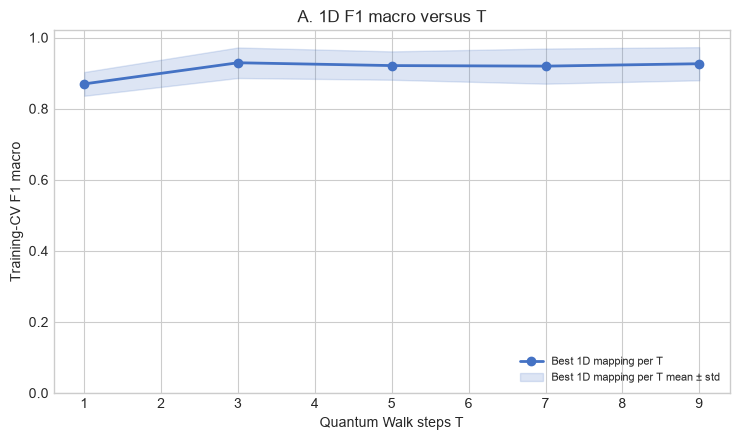

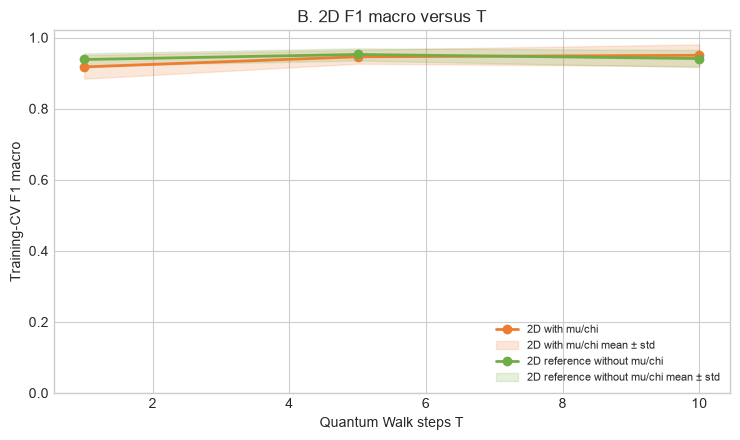

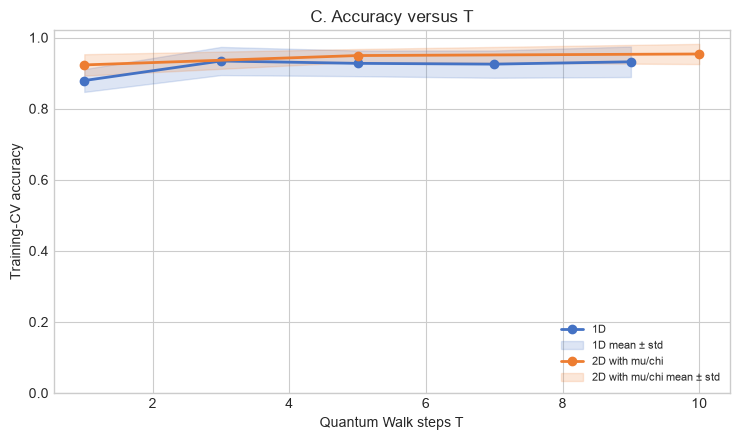

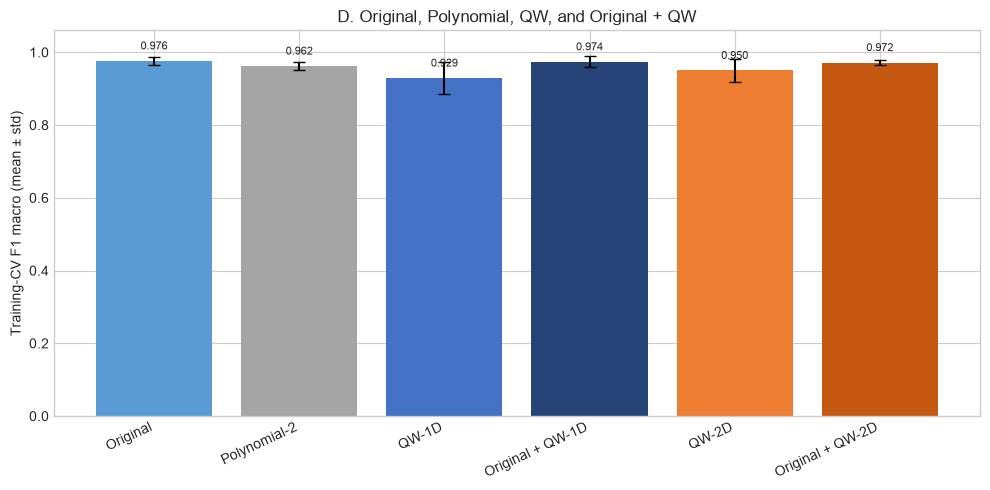

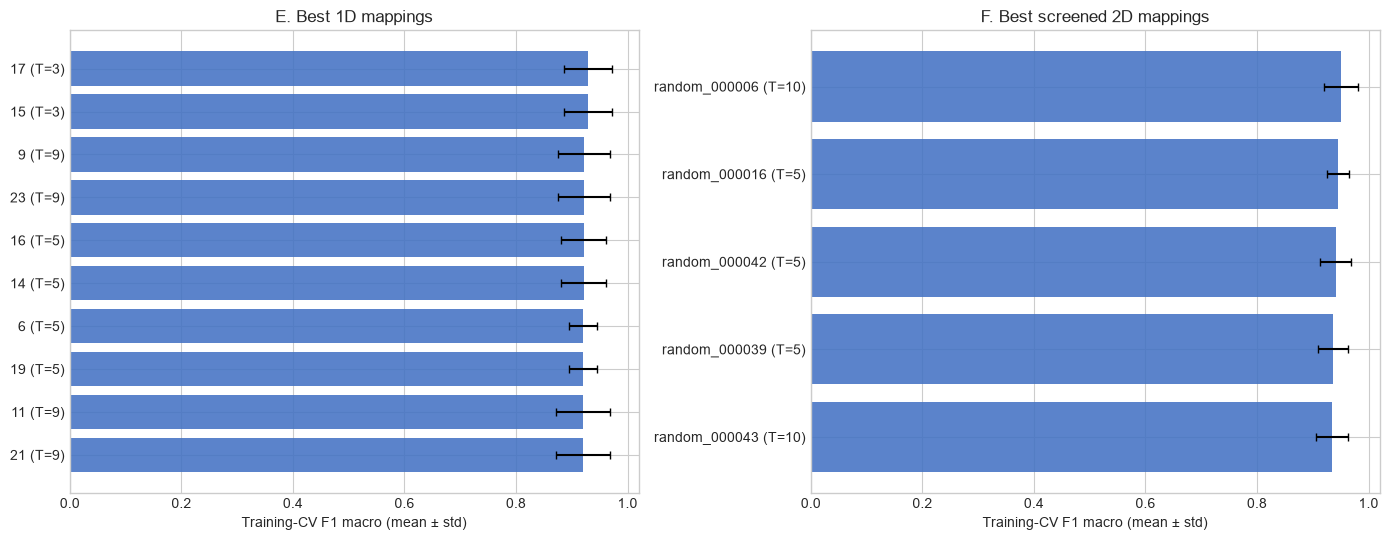

G. The selected-feature absolute-correlation heatmap is rendered in Section 9.1 from training data only.


In [18]:
def _completed_qw_results(results):
    if results is None or results.empty:
        return pd.DataFrame()
    return results.loc[results["status"].eq("completed")].copy()


def _best_configuration_per_T(results, metric_mean):
    completed = _completed_qw_results(results)
    if completed.empty:
        return completed
    return (
        completed.sort_values(
            ["T", metric_mean, "accuracy_mean"],
            ascending=[True, False, False],
            kind="mergesort",
        )
        .drop_duplicates("T")
        .sort_values("T")
    )


def _draw_unavailable(ax, title):
    ax.set_title(title)
    ax.text(
        0.5,
        0.5,
        "Available after external QW integration",
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="dimgray",
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("lightgray")


def _plot_best_metric_vs_T(ax, results, metric, label, color):
    best_by_T = _best_configuration_per_T(results, f"{metric}_mean")
    if best_by_T.empty:
        return False
    x = best_by_T["T"].to_numpy(dtype=float)
    mean = best_by_T[f"{metric}_mean"].to_numpy(dtype=float)
    std = best_by_T[f"{metric}_std"].to_numpy(dtype=float)
    ax.plot(x, mean, marker="o", linewidth=2, label=label, color=color)
    ax.fill_between(
        x,
        np.clip(mean - std, 0.0, 1.0),
        np.clip(mean + std, 0.0, 1.0),
        alpha=0.18,
        color=color,
        label=f"{label} mean ± std",
    )
    return True


def _fold_summary_from_result(result, field, metric):
    values = np.asarray([row[metric] for row in result[field]], dtype=float)
    return float(values.mean()), float(values.std(ddof=1))


def _cv_feature_space_plot_table():
    rows = [
        {
            "feature_space": "Original",
            "f1_macro_mean": original_cv_scores[PRIMARY_METRIC].mean(),
            "f1_macro_std": original_cv_scores[PRIMARY_METRIC].std(ddof=1),
        },
        {
            "feature_space": "Polynomial-2",
            "f1_macro_mean": polynomial_cv_scores[PRIMARY_METRIC].mean(),
            "f1_macro_std": polynomial_cv_scores[PRIMARY_METRIC].std(ddof=1),
        },
    ]
    for label, results in (
        ("QW-1D", results_1d_df),
        ("QW-2D", results_2d_with_mu_chi_df),
    ):
        completed = _completed_qw_results(results)
        if not completed.empty:
            best = completed.iloc[0]
            rows.append(
                {
                    "feature_space": label,
                    "f1_macro_mean": best["f1_macro_mean"],
                    "f1_macro_std": best["f1_macro_std"],
                }
            )
            hybrid_mean, hybrid_std = _fold_summary_from_result(
                best, "hybrid_fold_validation_scores", PRIMARY_METRIC
            )
            rows.append(
                {
                    "feature_space": f"Original + {label}",
                    "f1_macro_mean": hybrid_mean,
                    "f1_macro_std": hybrid_std,
                }
            )
        else:
            for unavailable_label in (label, f"Original + {label}"):
                rows.append(
                    {
                        "feature_space": unavailable_label,
                        "f1_macro_mean": np.nan,
                        "f1_macro_std": np.nan,
                    }
                )
    order = [
        "Original",
        "Polynomial-2",
        "QW-1D",
        "Original + QW-1D",
        "QW-2D",
        "Original + QW-2D",
    ]
    return pd.DataFrame(rows).set_index("feature_space").reindex(order).reset_index()


def _plot_top_mappings(ax, results, title, top_n=10):
    completed = _completed_qw_results(results)
    if completed.empty:
        _draw_unavailable(ax, title)
        return
    best_per_mapping = (
        completed.sort_values(
            ["f1_macro_mean", "accuracy_mean"],
            ascending=[False, False],
            kind="mergesort",
        )
        .drop_duplicates("mapping_id")
        .head(top_n)
        .sort_values("f1_macro_mean")
    )
    labels = [f"{mapping_id} (T={T})" for mapping_id, T in zip(
        best_per_mapping["mapping_id"], best_per_mapping["T"]
    )]
    ax.barh(
        labels,
        best_per_mapping["f1_macro_mean"],
        xerr=best_per_mapping["f1_macro_std"],
        color="#4472C4",
        alpha=0.88,
        capsize=3,
    )
    ax.set_xlim(0.0, 1.02)
    ax.set_xlabel("Training-CV F1 macro (mean ± std)")
    ax.set_title(title)


# A. F1 macro versus T for 1D.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
if _plot_best_metric_vs_T(
    ax, results_1d_df, "f1_macro", "Best 1D mapping per T", "#4472C4"
):
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV F1 macro")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("A. 1D F1 macro versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "A. 1D F1 macro versus T")
fig.tight_layout()
plt.show()


# B. F1 macro versus T for 2D, including the reference condition when available.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plotted_2d = _plot_best_metric_vs_T(
    ax,
    results_2d_with_mu_chi_df,
    "f1_macro",
    "2D with mu/chi",
    "#ED7D31",
)
plotted_2d |= _plot_best_metric_vs_T(
    ax,
    results_2d_without_mu_chi_df,
    "f1_macro",
    "2D reference without mu/chi",
    "#70AD47",
)
if plotted_2d:
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV F1 macro")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("B. 2D F1 macro versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "B. 2D F1 macro versus T")
fig.tight_layout()
plt.show()


# C. Accuracy versus T for both dimensions.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plotted_accuracy = _plot_best_metric_vs_T(
    ax, results_1d_df, "accuracy", "1D", "#4472C4"
)
plotted_accuracy |= _plot_best_metric_vs_T(
    ax, results_2d_with_mu_chi_df, "accuracy", "2D with mu/chi", "#ED7D31"
)
if plotted_accuracy:
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("C. Accuracy versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "C. Accuracy versus T")
fig.tight_layout()
plt.show()


# D. Four conceptual feature spaces, with 1D and 2D QW variants shown separately.
cv_feature_space_plot_df = _cv_feature_space_plot_table()
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(cv_feature_space_plot_df))
means = cv_feature_space_plot_df["f1_macro_mean"].to_numpy(dtype=float)
stds = cv_feature_space_plot_df["f1_macro_std"].to_numpy(dtype=float)
bars = ax.bar(
    x_positions,
    np.nan_to_num(means, nan=0.0),
    yerr=np.nan_to_num(stds, nan=0.0),
    color=["#5B9BD5", "#A5A5A5", "#4472C4", "#264478", "#ED7D31", "#C65911"],
    capsize=4,
)
for index, (bar, value) in enumerate(zip(bars, means)):
    if np.isfinite(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.025, 1.01),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    else:
        ax.text(index, 0.03, "N/A", ha="center", va="bottom", color="dimgray")
ax.set_xticks(x_positions)
ax.set_xticklabels(cv_feature_space_plot_df["feature_space"], rotation=25, ha="right")
ax.set_ylim(0.0, 1.06)
ax.set_ylabel("Training-CV F1 macro (mean ± std)")
ax.set_title("D. Original, Polynomial, QW, and Original + QW")
fig.tight_layout()
plt.show()


# E-F. Best mappings after training-only evaluation.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
_plot_top_mappings(axes[0], results_1d_df, "E. Best 1D mappings")
_plot_top_mappings(
    axes[1], results_2d_with_mu_chi_df, "F. Best screened 2D mappings"
)
fig.tight_layout()
plt.show()

print(
    "G. The selected-feature absolute-correlation heatmap is rendered in "
    "Section 9.1 from training data only."
)


# 17. Final Six-space Test Evaluation

This is the first section that transforms or evaluates the reserved Test set. Every feature space uses the original stratified split, the same metrics, and the same `StandardScaler` + `LogisticRegression` evaluator.

`Original` and `Polynomial-2` retain all 30 classical inputs. `QW-1D` is generated from four training-selected classical inputs, while `QW-2D` is generated from ten. The hybrid rows retain all 30 original inputs and append the corresponding QW representation. `source_feature_count` counts unique classical inputs available to the whole model; `qw_source_feature_count` separately exposes the four- versus ten-feature QW branch.

QW Test features are created only from the rank-one mapping and $T$ found by training-only validation. Mutual-information selection and min–max encoding are re-fitted on all training data, and the fitted transforms are applied to the Test inputs exactly once. Test labels never participate in selection, mapping, $T$, scaling, or feature generation.


In [19]:
FINAL_COMPARISON_COLUMNS = [
    "dimension",
    "feature_space",
    "selected_features",
    "source_feature_count",
    "qw_source_feature_count",
    "mapping_id",
    "T",
    "final_dimension",
    "accuracy",
    "f1_macro",
    "f1_malignant",
    "precision_malignant",
    "recall_malignant",
    "status",
]


def evaluate_final_feature_space(
    X_fit,
    X_evaluation,
    y_fit,
    y_evaluation,
    *,
    dimension,
    feature_space,
    selected_features,
    source_feature_count,
    qw_source_feature_count=None,
    mapping_id=None,
    T=None,
    prediction_store=None,
):
    """Evaluate one fixed feature space with the shared classifier architecture."""
    X_fit_array = np.asarray(X_fit, dtype=float)
    X_evaluation_array = np.asarray(X_evaluation, dtype=float)
    if X_fit_array.ndim != 2 or X_evaluation_array.ndim != 2:
        raise ValueError("Final feature matrices must be two-dimensional.")
    if X_fit_array.shape[1] != X_evaluation_array.shape[1]:
        raise ValueError("Training and Test feature dimensions must match.")
    if not np.all(np.isfinite(X_fit_array)) or not np.all(
        np.isfinite(X_evaluation_array)
    ):
        raise ValueError("Final feature matrices must contain only finite values.")

    evaluation = evaluate_classifier(
        X_fit_array,
        X_evaluation_array,
        y_fit,
        y_evaluation,
    )
    if prediction_store is not None:
        y_true = np.asarray(y_evaluation)
        predictions = np.asarray(evaluation["predictions"])
        prediction_store[feature_space] = {
            "predictions": predictions.copy(),
            "correctness": (predictions == y_true),
            "y_true": y_true.copy(),
        }
    return {
        "dimension": dimension,
        "feature_space": feature_space,
        "selected_features": selected_features,
        "source_feature_count": int(source_feature_count),
        "qw_source_feature_count": (
            None
            if qw_source_feature_count is None
            else int(qw_source_feature_count)
        ),
        "mapping_id": mapping_id,
        "T": None if T is None else int(T),
        "final_dimension": int(X_fit_array.shape[1]),
        **{metric: float(evaluation[metric]) for metric in METRIC_COLUMNS},
        "status": "evaluated on reserved Test set",
    }


def _unavailable_final_qw_record(
    *,
    dimension,
    feature_space,
    selected_features,
    source_feature_count,
    hybrid,
):
    return {
        "dimension": dimension,
        "feature_space": feature_space,
        "selected_features": selected_features,
        "source_feature_count": int(X_train.shape[1] if hybrid else source_feature_count),
        "qw_source_feature_count": int(source_feature_count),
        "mapping_id": None,
        "T": None,
        "final_dimension": np.nan,
        **{metric: np.nan for metric in METRIC_COLUMNS},
        "status": "not evaluated: external QW runner/search result unavailable",
    }


def _best_training_only_configuration(results, expected_dimension):
    """Read the top configuration from training-CV results only."""
    best = _best_completed_configuration(results)
    if best["dimension"] != expected_dimension:
        raise ValueError(
            f"Expected a {expected_dimension} training-CV result, got {best['dimension']}."
        )
    if best["stage"] not in {"full", "exhaustive_full"}:
        raise ValueError("Final evaluation requires a completed full-stage result.")
    return best


def build_final_qw_train_test_features(
    X_training,
    y_training,
    X_test_reserved,
    *,
    best_configuration,
    qw_runner,
    dimension,
    use_mu_chi=None,
):
    """Fit all classical preprocessing on training data, then transform Test once."""
    if dimension == "1D":
        k = len(PARAMS_1D)
        param_order = PARAMS_1D
        param_ranges = PARAM_RANGES_1D
    elif dimension == "2D":
        k = len(PARAMS_2D)
        param_order = PARAMS_2D
        param_ranges = PARAM_RANGES_2D
    else:
        raise ValueError("dimension must be '1D' or '2D'.")

    if best_configuration["dimension"] != dimension:
        raise ValueError("The selected configuration has the wrong dimension.")
    mapping = dict(best_configuration["mapping"])
    _, parameter_sequence = _mapping_parameter_sequence(
        {"mapping": mapping}, param_order
    )

    # y_test is intentionally absent: selection sees training labels only.
    selected = select_features_mi(
        X_training,
        y_training,
        X_test_reserved,
        k=k,
    )
    selected_names = tuple(selected["selected_feature_names"])
    final_mapping = dict(zip(selected_names, parameter_sequence))

    scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
    X_training_unit = scaler.fit_transform(selected["X_train"])
    X_test_unit = scaler.transform(selected["X_eval"])
    training_parameters = apply_feature_parameter_mapping(
        X_training_unit,
        selected_names,
        final_mapping,
        param_order,
        param_ranges,
    )
    test_parameters = apply_feature_parameter_mapping(
        X_test_unit,
        selected_names,
        final_mapping,
        param_order,
        param_ranges,
    )

    T = int(best_configuration["T"])
    if dimension == "1D":
        X_training_qw = build_qw_feature_matrix_1d(
            training_parameters, T, qw_runner
        )
        X_test_qw = build_qw_feature_matrix_1d(test_parameters, T, qw_runner)
    else:
        X_training_qw = build_qw_feature_matrix_2d(
            training_parameters,
            T,
            qw_runner,
            use_mu_chi=use_mu_chi,
        )
        X_test_qw = build_qw_feature_matrix_2d(
            test_parameters,
            T,
            qw_runner,
            use_mu_chi=use_mu_chi,
        )
    if tuple(X_training_qw.columns) != tuple(X_test_qw.columns):
        raise ValueError("Training and Test QW feature schemas differ.")

    return {
        "X_training": X_training_qw,
        "X_test": X_test_qw,
        "selected_features": selected_names,
        "mapping": final_mapping,
        "mapping_id": best_configuration["mapping_id"],
        "T": T,
        "qw_feature_names": tuple(X_training_qw.columns),
        "selector": selected["selector"],
        "minmax_scaler": scaler,
    }


def concatenate_original_and_qw(X_original_values, X_qw_values):
    """Concatenate by row position and use distinct, auditable column prefixes."""
    original_array = np.asarray(X_original_values, dtype=float)
    qw_array = np.asarray(X_qw_values, dtype=float)
    if original_array.ndim != 2 or qw_array.ndim != 2:
        raise ValueError("Both feature matrices must be two-dimensional.")
    if original_array.shape[0] != qw_array.shape[0]:
        raise ValueError("Original and QW matrices must contain the same rows.")
    combined = np.hstack([original_array, qw_array])
    if not np.all(np.isfinite(combined)):
        raise ValueError("Combined features must contain only finite values.")
    return combined


def append_qw_final_comparisons(
    records,
    *,
    dimension,
    training_results,
    qw_runner,
    use_mu_chi=None,
    prediction_store=None,
):
    """Evaluate QW-only and Original+QW from one fixed training-selected setup."""
    best = _best_training_only_configuration(training_results, dimension)
    artifacts = build_final_qw_train_test_features(
        X_train,
        y_train,
        X_test,
        best_configuration=best,
        qw_runner=qw_runner,
        dimension=dimension,
        use_mu_chi=use_mu_chi,
    )
    label = "1D" if dimension == "1D" else "2D"
    source_count = len(PARAMS_1D) if dimension == "1D" else len(PARAMS_2D)

    records.append(
        evaluate_final_feature_space(
            artifacts["X_training"],
            artifacts["X_test"],
            y_train,
            y_test,
            dimension=dimension,
            feature_space=f"QW-{label}",
            selected_features=artifacts["selected_features"],
            source_feature_count=source_count,
            qw_source_feature_count=source_count,
            mapping_id=artifacts["mapping_id"],
            T=artifacts["T"],
            prediction_store=prediction_store,
        )
    )

    X_training_combined = concatenate_original_and_qw(
        X_train, artifacts["X_training"]
    )
    X_test_combined = concatenate_original_and_qw(X_test, artifacts["X_test"])
    records.append(
        evaluate_final_feature_space(
            X_training_combined,
            X_test_combined,
            y_train,
            y_test,
            dimension=dimension,
            feature_space=f"Original + QW-{label}",
            selected_features={
                "original": tuple(X_train.columns),
                "qw_branch": artifacts["selected_features"],
            },
            # Unique classical source variables remain the original 30; the
            # separate branch-count column shows 4 versus 10 for QW.
            source_feature_count=X_train.shape[1],
            qw_source_feature_count=source_count,
            mapping_id=artifacts["mapping_id"],
            T=artifacts["T"],
            prediction_store=prediction_store,
        )
    )
    return artifacts


# This is the first post-split section that transforms or evaluates X_test.
final_comparison_records = []
final_prediction_store = {}

# The classical baselines retain all 30 inputs and are not compressed.
final_comparison_records.append(
    evaluate_final_feature_space(
        X_train,
        X_test,
        y_train,
        y_test,
        dimension="Classical",
        feature_space="Original",
        selected_features=tuple(X_train.columns),
        source_feature_count=X_train.shape[1],
        prediction_store=final_prediction_store,
    )
)

final_polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_polynomial_final = final_polynomial_transformer.fit_transform(X_train)
X_test_polynomial_final = final_polynomial_transformer.transform(X_test)
final_comparison_records.append(
    evaluate_final_feature_space(
        X_train_polynomial_final,
        X_test_polynomial_final,
        y_train,
        y_test,
        dimension="Classical",
        feature_space="Polynomial-2",
        selected_features=tuple(X_train.columns),
        source_feature_count=X_train.shape[1],
        prediction_store=final_prediction_store,
    )
)

def _append_unavailable_dimension_records(dimension, source_count, selected_names):
    final_comparison_records.append(
        _unavailable_final_qw_record(
            dimension=dimension,
            feature_space=f"QW-{dimension}",
            selected_features=selected_names,
            source_feature_count=source_count,
            hybrid=False,
        )
    )
    final_comparison_records.append(
        _unavailable_final_qw_record(
            dimension=dimension,
            feature_space=f"Original + QW-{dimension}",
            selected_features={
                "original": tuple(X_train.columns),
                "qw_branch": selected_names,
            },
            source_feature_count=source_count,
            hybrid=True,
        )
    )


final_qw_artifacts = {}
if RUN_QW_1D_EXPERIMENTS:
    final_qw_artifacts["1D"] = append_qw_final_comparisons(
        final_comparison_records,
        dimension="1D",
        training_results=results_1d_df,
        qw_runner=quantum_walk_1d,
        prediction_store=final_prediction_store,
    )
else:
    _append_unavailable_dimension_records(
        "1D", len(PARAMS_1D), tuple(features_1d["names"])
    )

if RUN_QW_2D_EXPERIMENTS:
    final_qw_artifacts["2D"] = append_qw_final_comparisons(
        final_comparison_records,
        dimension="2D",
        training_results=results_2d_with_mu_chi_df,
        qw_runner=quantum_walk_2d,
        use_mu_chi=True,
        prediction_store=final_prediction_store,
    )
else:
    _append_unavailable_dimension_records(
        "2D", len(PARAMS_2D), tuple(features_2d["names"])
    )

final_comparison_df = pd.DataFrame(
    final_comparison_records,
    columns=FINAL_COMPARISON_COLUMNS,
)
final_test_results = final_comparison_df  # Backward-compatible notebook alias.

assert final_comparison_df["feature_space"].tolist() == [
    "Original",
    "Polynomial-2",
    "QW-1D",
    "Original + QW-1D",
    "QW-2D",
    "Original + QW-2D",
]
assert final_comparison_df["source_feature_count"].tolist() == [
    30, 30, 4, 30, 10, 30
]
assert final_comparison_df.loc[
    final_comparison_df["feature_space"] == "Original", "final_dimension"
].iloc[0] == 30

display(final_comparison_df)


,dimension,feature_space,selected_features,source_feature_count,qw_source_feature_count,mapping_id,T,final_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant,status
0,Classical,Original,"(mean radius, mean texture, mean perimeter, me...",30,NaN,None,NaN,30,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
1,Classical,Polynomial-2,"(mean radius, mean texture, mean perimeter, me...",30,NaN,None,NaN,495,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
2,1D,QW-1D,"(mean concave points, worst radius, worst peri...",4,4.0,15,3.0,8,0.921053,0.916361,0.896552,0.866667,0.928571,evaluated on reserved Test set
3,1D,Original + QW-1D,"{'original': ('mean radius', 'mean texture', '...",30,4.0,15,3.0,38,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
4,2D,QW-2D,"(mean radius, mean perimeter, mean area, mean ...",10,10.0,random_000006,10.0,9,0.938596,0.934348,0.917647,0.906977,0.928571,evaluated on reserved Test set
5,2D,Original + QW-2D,"{'original': ('mean radius', 'mean texture', '...",30,10.0,random_000006,10.0,39,0.964912,0.962660,0.953488,0.931818,0.976190,evaluated on reserved Test set


# 18. Paired Statistical Results

The table below prepares every required method pair at `alpha = 0.05`. Wilcoxon rows use the common training-validation folds and McNemar rows use correctness on identical final Test samples. QW-dependent rows remain warning records until external QW runners produce training-selected configurations and final predictions.

These tests assess paired differences only after configuration selection. They do not feed back into mapping or $T$ selection, and the Test set is never reused for configuration tuning. Statistical significance is not inferred from one scalar metric.


In [20]:
def _fold_metric_vector(result_row, score_field, metric):
    if result_row is None:
        return None
    fold_records = result_row.get(score_field)
    if not fold_records:
        return None
    try:
        return np.asarray([record[metric] for record in fold_records], dtype=float)
    except (KeyError, TypeError, ValueError):
        return None


cv_score_registry = {
    "Original": {
        metric: original_cv_scores[metric].to_numpy(dtype=float)
        for metric in METRIC_COLUMNS
    },
    "Polynomial-2": {
        metric: polynomial_cv_scores[metric].to_numpy(dtype=float)
        for metric in METRIC_COLUMNS
    },
}

if RUN_QW_1D_EXPERIMENTS:
    _best_1d_stats = _best_training_only_configuration(results_1d_df, "1D")
    cv_score_registry.update(
        {
            "QW-1D": {
                metric: _fold_metric_vector(
                    _best_1d_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "Original + QW-1D": {
                metric: _fold_metric_vector(
                    _best_1d_stats, "hybrid_fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
        }
    )

if RUN_QW_2D_EXPERIMENTS:
    _best_2d_with_stats = _best_training_only_configuration(
        results_2d_with_mu_chi_df, "2D"
    )
    _best_2d_without_stats = _best_training_only_configuration(
        results_2d_without_mu_chi_df, "2D"
    )
    cv_score_registry.update(
        {
            "QW-2D": {
                metric: _fold_metric_vector(
                    _best_2d_with_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "Original + QW-2D": {
                metric: _fold_metric_vector(
                    _best_2d_with_stats, "hybrid_fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "2D with mu/chi": {
                metric: _fold_metric_vector(
                    _best_2d_with_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "2D without mu/chi": {
                metric: _fold_metric_vector(
                    _best_2d_without_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
        }
    )


requested_paired_comparisons = [
    ("Original", "QW-1D"),
    ("Polynomial-2", "QW-1D"),
    ("Original", "Original + QW-1D"),
    ("Original", "QW-2D"),
    ("Polynomial-2", "QW-2D"),
    ("Original", "Original + QW-2D"),
    ("QW-1D", "QW-2D"),
    ("2D without mu/chi", "2D with mu/chi"),
]

statistical_result_records = []
for method_A, method_B in requested_paired_comparisons:
    scores_A = cv_score_registry.get(method_A, {}).get(PRIMARY_METRIC)
    scores_B = cv_score_registry.get(method_B, {}).get(PRIMARY_METRIC)
    statistical_result_records.append(
        paired_wilcoxon_comparison(
            method_A,
            method_B,
            PRIMARY_METRIC,
            scores_A,
            scores_B,
            alpha=ALPHA,
        )
    )

# This classical comparison provides an immediately executable software path.
statistical_result_records.append(
    paired_wilcoxon_comparison(
        "Original",
        "Polynomial-2",
        PRIMARY_METRIC,
        cv_score_registry["Original"][PRIMARY_METRIC],
        cv_score_registry["Polynomial-2"][PRIMARY_METRIC],
        alpha=ALPHA,
    )
)


def _stored_correctness(method):
    stored = final_prediction_store.get(method)
    return None if stored is None else stored["correctness"]


for method_A, method_B in requested_paired_comparisons[:-1]:
    statistical_result_records.append(
        exact_mcnemar_comparison(
            method_A,
            method_B,
            _stored_correctness(method_A),
            _stored_correctness(method_B),
            alpha=ALPHA,
        )
    )

statistical_result_records.append(
    exact_mcnemar_comparison(
        "Original",
        "Polynomial-2",
        _stored_correctness("Original"),
        _stored_correctness("Polynomial-2"),
        alpha=ALPHA,
    )
)

statistical_results_df = pd.DataFrame(
    statistical_result_records,
    columns=STATISTICAL_RESULT_COLUMNS,
)

assert set(
    statistical_results_df.loc[
        statistical_results_df["test_name"] == "Wilcoxon signed-rank",
        ["method_A", "method_B"],
    ].itertuples(index=False, name=None)
).issuperset(requested_paired_comparisons)
assert statistical_results_df["alpha"].eq(0.05).all()

display(statistical_results_df)
print(
    "Statistical significance is based on paired score/correctness vectors, "
    "never on a single scalar accuracy. Review the warning column before interpretation."
)


,method_A,method_B,metric,test_name,statistic,p_value,alpha,significant,n_pairs,warning
0,Original,QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
1,Polynomial-2,QW-1D,f1_macro,Wilcoxon signed-rank,2.0,0.187500,0.05,False,5,exploratory: only five folds are available and...
2,Original,Original + QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.500000,0.05,False,5,exploratory: only five folds are available and...
3,Original,QW-2D,f1_macro,Wilcoxon signed-rank,1.0,0.250000,0.05,False,5,exploratory: only five folds are available and...
4,Polynomial-2,QW-2D,f1_macro,Wilcoxon signed-rank,5.0,0.625000,0.05,False,5,exploratory: only five folds are available and...
5,Original,Original + QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.875000,0.05,False,5,exploratory: only five folds are available and...
6,QW-1D,QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.437500,0.05,False,5,exploratory: only five folds are available and...
7,2D without mu/chi,2D with mu/chi,f1_macro,Wilcoxon signed-rank,7.0,1.000000,0.05,False,5,exploratory: only five folds are available and...
8,Original,Polynomial-2,f1_macro,Wilcoxon signed-rank,0.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
9,Original,QW-1D,correctness,Exact McNemar (binomial),1.0,0.039062,0.05,True,114,"exact test is valid with 9 discordant pairs, b..."


Statistical significance is based on paired score/correctness vectors, never on a single scalar accuracy. Review the warning column before interpretation.


# 19. Final Summary Tables and Reproducibility

Tables A–G consolidate the classical baselines, selected QW configurations, four conceptual feature spaces, dimensional comparison, `mu/chi` comparison, and paired statistical tests. QW tables use explicit unavailable rows if a configured run does not complete; no values are imputed.

The reproducibility table records the fixed data split, preprocessing, estimator, selected classical features, parameter ranges, $T$ ranges, and cross-validation design used by the notebook.


In [21]:
def _baseline_table_row(label, fold_scores, input_dimension):
    row = {
        "feature_space": label,
        "source_feature_count": X_train.shape[1],
        "final_dimension": int(input_dimension),
    }
    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = float(fold_scores[metric].mean())
        row[f"{metric}_std"] = float(fold_scores[metric].std(ddof=1))
    return row


table_A_classical_baselines = pd.DataFrame(
    [
        _baseline_table_row("Original", original_cv_scores, X_train.shape[1]),
        _baseline_table_row(
            "Polynomial-2",
            polynomial_cv_scores,
            X_train_polynomial.shape[1],
        ),
    ]
)


def _best_qw_configuration_table(results, dimension, unavailable_status):
    completed = _completed_qw_results(results)
    if completed.empty:
        return pd.DataFrame(
            [
                {
                    "dimension": dimension,
                    "mapping_id": None,
                    "mapping": None,
                    "T": None,
                    "selected_features": None,
                    "qw_feature_names": None,
                    "qw_feature_dimension": np.nan,
                    "accuracy_mean": np.nan,
                    "accuracy_std": np.nan,
                    "f1_macro_mean": np.nan,
                    "f1_macro_std": np.nan,
                    "runtime_sec": np.nan,
                    "status": unavailable_status,
                }
            ]
        )
    best = completed.iloc[0]
    columns = [
        "dimension",
        "mapping_id",
        "mapping",
        "T",
        "selected_features",
        "qw_feature_names",
        "qw_feature_dimension",
        "accuracy_mean",
        "accuracy_std",
        "f1_macro_mean",
        "f1_macro_std",
        "runtime_sec",
        "status",
    ]
    return pd.DataFrame([{column: best[column] for column in columns}])


table_B_best_1d_qw = _best_qw_configuration_table(
    results_1d_df,
    "1D",
    "awaiting external 1D QW runner",
)
table_C_best_2d_qw = _best_qw_configuration_table(
    results_2d_with_mu_chi_df,
    "2D",
    "awaiting external 2D QW runner",
)

table_D_four_feature_spaces = final_comparison_df.copy()
table_E_1d_vs_2d = pd.concat(
    [
        table_B_best_1d_qw.assign(comparison_label="QW-1D"),
        table_C_best_2d_qw.assign(comparison_label="QW-2D"),
    ],
    ignore_index=True,
)[
    [
        "comparison_label",
        "mapping_id",
        "T",
        "qw_feature_dimension",
        "accuracy_mean",
        "accuracy_std",
        "f1_macro_mean",
        "f1_macro_std",
        "status",
    ]
]

if RUN_QW_2D_EXPERIMENTS and not mu_chi_comparison_df.empty:
    table_F_mu_chi_comparison = mu_chi_comparison_df.copy()
else:
    table_F_mu_chi_comparison = pd.DataFrame(
        [
            {
                "condition": "2D with mu/chi",
                "best_mapping": None,
                "best_T": None,
                "accuracy_mean": np.nan,
                "f1_macro_mean": np.nan,
                "search_scope": "awaiting external 2D QW runner",
            },
            {
                "condition": "2D reference without mu/chi",
                "best_mapping": None,
                "best_T": None,
                "accuracy_mean": np.nan,
                "f1_macro_mean": np.nan,
                "search_scope": "awaiting external 2D QW runner",
            },
        ]
    )

table_G_statistical_significance = statistical_results_df.copy()

reproducibility_summary_df = pd.DataFrame(
    [
        ("random_state", RANDOM_STATE),
        ("dataset", "Breast Cancer Wisconsin (Diagnostic), scikit-learn"),
        ("train/test ratio", "80/20 stratified"),
        ("feature selection method", "SelectKBest with mutual information; training only"),
        ("classifier", "StandardScaler + LogisticRegression(max_iter=5000)"),
        ("polynomial degree", 2),
        ("1D selected features", tuple(features_1d["names"])),
        ("2D selected features", tuple(features_2d["names"])),
        ("1D parameter ranges", PARAM_RANGES_1D),
        ("2D parameter ranges", PARAM_RANGES_2D),
        ("1D T range", tuple(T_VALUES_1D)),
        ("2D T range", tuple(T_VALUES_2D)),
        (
            "CV strategy",
            f"Stratified {N_SPLITS}-fold, shuffled, random_state={RANDOM_STATE}",
        ),
    ],
    columns=["setting", "value"],
)

for label, table in (
    ("Table A. Classical Baselines", table_A_classical_baselines),
    ("Table B. Best 1D QW Configuration", table_B_best_1d_qw),
    ("Table C. Best 2D QW Configuration", table_C_best_2d_qw),
    ("Table D. Four Feature Spaces", table_D_four_feature_spaces),
    ("Table E. 1D vs 2D", table_E_1d_vs_2d),
    ("Table F. mu/chi Comparison", table_F_mu_chi_comparison),
    ("Table G. Statistical Significance", table_G_statistical_significance),
):
    print(label)
    display(table)

print("Reproducibility summary")
display(reproducibility_summary_df)


Table A. Classical Baselines


,feature_space,source_feature_count,final_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_malignant_mean,f1_malignant_std,precision_malignant_mean,precision_malignant_std,recall_malignant_mean,recall_malignant_std
0,Original,30,30,0.978022,0.010989,0.976426,0.011862,0.970308,0.015085,0.976975,0.023958,0.964706,0.032219
1,Polynomial-2,30,495,0.964835,0.009194,0.962275,0.010036,0.952473,0.013003,0.959446,0.025324,0.947059,0.038348


Table B. Best 1D QW Configuration


,dimension,mapping_id,mapping,T,selected_features,qw_feature_names,qw_feature_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,runtime_sec,status
0,1D,15,"{'mean concave points': 'alpha1', 'worst radiu...",3,"((mean concave points, worst radius, worst per...","(mean, variance, skewness, kurtosis, shannon_e...",8,0.934066,0.039621,0.929153,0.042892,0.36022,completed


Table C. Best 2D QW Configuration


...

,condition,best_mapping,best_T,accuracy_mean,f1_macro_mean,search_scope
0,with_mu_chi,"{'mean radius': 'beta1', 'mean perimeter': 'be...",10,0.953846,0.950153,"sampled 50 of 3,628,800 mappings; retained top 5"
1,reference_without_mu_chi,"{'mean radius': 'theta2', 'mean perimeter': 't...",5,0.956044,0.952495,"sampled 50 of 3,628,800 mappings; retained top 5"


Table G. Statistical Significance


,method_A,method_B,metric,test_name,statistic,p_value,alpha,significant,n_pairs,warning
0,Original,QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
1,Polynomial-2,QW-1D,f1_macro,Wilcoxon signed-rank,2.0,0.187500,0.05,False,5,exploratory: only five folds are available and...
2,Original,Original + QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.500000,0.05,False,5,exploratory: only five folds are available and...
3,Original,QW-2D,f1_macro,Wilcoxon signed-rank,1.0,0.250000,0.05,False,5,exploratory: only five folds are available and...
4,Polynomial-2,QW-2D,f1_macro,Wilcoxon signed-rank,5.0,0.625000,0.05,False,5,exploratory: only five folds are available and...
5,Original,Original + QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.875000,0.05,False,5,exploratory: only five folds are available and...
6,QW-1D,QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.437500,0.05,False,5,exploratory: only five folds are available and...
7,2D without mu/chi,2D with mu/chi,f1_macro,Wilcoxon signed-rank,7.0,1.000000,0.05,False,5,exploratory: only five folds are available and...
8,Original,Polynomial-2,f1_macro,Wilcoxon signed-rank,0.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
9,Original,QW-1D,correctness,Exact McNemar (binomial),1.0,0.039062,0.05,True,114,"exact test is valid with 9 discordant pairs, b..."


Reproducibility summary


,setting,value
0,random_state,42
1,dataset,"Breast Cancer Wisconsin (Diagnostic), scikit-l..."
2,train/test ratio,80/20 stratified
3,feature selection method,SelectKBest with mutual information; training ...
4,classifier,StandardScaler + LogisticRegression(max_iter=5...
5,polynomial degree,2
6,1D selected features,"(mean concave points, worst radius, worst peri..."
7,2D selected features,"(mean radius, mean perimeter, mean area, mean ..."
8,1D parameter ranges,"{'theta1': (0, 3.141592653589793), 'phi1': (0,..."
9,2D parameter ranges,"{'theta1': (0, 3.141592653589793), 'phi1': (0,..."


# 20. Final Automated Sanity Checks

The final executable audit checks feature counts, mapping cardinality, classical metric completeness, Train/Test separation, encoded parameter dimensions, probability normalization at the QW interface, finite generated QW features, and the opt-in execution flag. External QW outputs are rejected by the existing validator before feature extraction if normalization or finiteness fails.


In [22]:
sanity_checks = []


def _record_sanity_check(name, passed, detail):
    sanity_checks.append(
        {"check": name, "passed": bool(passed), "detail": str(detail)}
    )


_record_sanity_check(
    "Exactly four selected 1D features",
    len(features_1d["names"]) == 4,
    len(features_1d["names"]),
)
_record_sanity_check(
    "Exactly ten selected 2D features",
    len(features_2d["names"]) == 10,
    len(features_2d["names"]),
)
_record_sanity_check(
    "Exactly 24 exhaustive 1D mappings",
    len(mappings_1d) == math.factorial(4) == 24,
    len(mappings_1d),
)

classical_metric_values = table_A_classical_baselines.filter(
    regex=r"_(mean|std)$"
).to_numpy(dtype=float)
_record_sanity_check(
    "Classical baseline metrics contain no NaN",
    np.all(np.isfinite(classical_metric_values)),
    f"checked {classical_metric_values.size} mean/std values",
)

# Static audit complements the structural guarantee that Test processing first
# appears only in the final-evaluation section.
with open("Main_Code.ipynb", encoding="utf-8") as notebook_handle:
    notebook_text = notebook_handle.read()
compact_notebook_text = "".join(notebook_text.split())
leakage_patterns = [
    ".fi" + "t(X_test",
    ".fit_" + "transform(X_test",
    "select_features_" + "mi(X_test",
]
found_leakage_patterns = [
    pattern for pattern in leakage_patterns if pattern in compact_notebook_text
]
split_indices_disjoint = set(X_train.index).isdisjoint(set(X_test.index))
_record_sanity_check(
    "No leakage-prone fitting on Test data",
    not found_leakage_patterns and split_indices_disjoint,
    (
        "no fit/fit_transform/feature-selection call starts from X_test; "
        "Train/Test indices are disjoint"
    ),
)

_record_sanity_check(
    "Encoded parameter matrices have correct dimensions",
    X_train_params_1d.shape == (len(X_train), 4)
    and X_train_params_2d.shape == (len(X_train), 10),
    f"1D={X_train_params_1d.shape}, 2D={X_train_params_2d.shape}",
)

mock_output_1d = _software_test_mock_walk_1d(np.zeros(4), T=1)
mock_output_2d = _software_test_mock_walk_2d(np.zeros(10), T=1)
probability_sums = [
    float(mock_output_1d["probabilities"].sum()),
    float(mock_output_2d["probabilities"].sum()),
]
_record_sanity_check(
    "Available QW outputs pass probability normalization",
    all(np.isclose(total, 1.0, atol=PROBABILITY_ATOL) for total in probability_sums),
    (
        f"mock sums={probability_sums}; every external output is validated "
        "by the feature builders before use"
    ),
)

generated_qw_matrices = [mock_features_1d_df, mock_features_2d_df]
for artifacts in final_qw_artifacts.values():
    generated_qw_matrices.extend([artifacts["X_training"], artifacts["X_test"]])
qw_matrices_finite = all(
    np.all(np.isfinite(np.asarray(matrix, dtype=float)))
    for matrix in generated_qw_matrices
)
_record_sanity_check(
    "Generated QW feature matrices contain finite values",
    qw_matrices_finite,
    f"checked {len(generated_qw_matrices)} generated matrices",
)

direct_1d_params = {
    "theta1": np.pi / 3,
    "phi1": 1.1,
    "alpha1": np.pi / 4,
    "beta1": 0.7,
}
direct_1d_outputs = [quantum_walk_1d(direct_1d_params, T) for T in (0, 1, 5)]
direct_1d_valid = all(
    output["positions"].shape == output["probabilities"].shape == (2 * T + 1,)
    and np.all(np.isfinite(output["probabilities"]))
    and np.all(output["probabilities"] >= -NEGATIVE_PROBABILITY_ATOL)
    and np.isclose(output["probabilities"].sum(), 1.0, atol=PROBABILITY_ATOL)
    for T, output in zip((0, 1, 5), direct_1d_outputs)
)
direct_1d_repeat = quantum_walk_1d(direct_1d_params, 5)
direct_1d_valid &= np.array_equal(
    direct_1d_outputs[-1]["probabilities"],
    direct_1d_repeat["probabilities"],
)
_record_sanity_check(
    "Integrated 1D runner satisfies its direct contract",
    direct_1d_valid and not quantum_walk_1d._is_physics_stub,
    "T=0/1/5 shapes, finiteness, non-negativity, normalization, determinism",
)

real_adapter_features = build_qw_feature_matrix_1d(
    np.array([[direct_1d_params[name] for name in PARAMS_1D]]),
    T=2,
    qw_runner=quantum_walk_1d,
)
_record_sanity_check(
    "1D matrix adapter uses the parameter-dictionary contract",
    tuple(real_adapter_features.columns) == QW_FEATURES_1D
    and np.all(np.isfinite(real_adapter_features.to_numpy())),
    f"columns={tuple(real_adapter_features.columns)}",
)

direct_2d_params = {
    "theta1": np.pi / 3,
    "phi1": 0.7,
    "alpha1": np.pi / 4,
    "beta1": 0.2,
    "theta2": np.pi / 2.5,
    "phi2": 1.3,
    "alpha2": np.pi / 5,
    "beta2": 0.9,
    "mu": np.pi / 3,
    "chi": 1.1,
}
direct_2d_outputs = [
    quantum_walk_2d(direct_2d_params, T, use_mu_chi=True)
    for T in (0, 1, 3)
]
direct_2d_valid = all(
    output["positions"].shape == ((2 * T + 1) ** 2, 2)
    and output["probabilities"].shape == ((2 * T + 1) ** 2,)
    and output["state"].shape == ((2 * T + 1) ** 2, 4)
    and np.all(np.isfinite(output["probabilities"]))
    and np.all(output["probabilities"] >= -NEGATIVE_PROBABILITY_ATOL)
    and np.isclose(output["probabilities"].sum(), 1.0, atol=PROBABILITY_ATOL)
    and np.allclose(
        output["probabilities"],
        np.sum(np.abs(output["state"]) ** 2, axis=1),
        atol=PROBABILITY_ATOL,
        rtol=0.0,
    )
    for T, output in zip((0, 1, 3), direct_2d_outputs)
)
direct_2d_repeat = quantum_walk_2d(direct_2d_params, 3, use_mu_chi=True)
direct_2d_valid &= np.array_equal(
    direct_2d_outputs[-1]["state"], direct_2d_repeat["state"]
)
reference_2d_params = dict(direct_2d_params, mu=0.0, chi=0.0)
reference_2d_output = quantum_walk_2d(
    reference_2d_params, 2, use_mu_chi=True
)
disabled_mu_chi_output = quantum_walk_2d(
    direct_2d_params, 2, use_mu_chi=False
)
direct_2d_valid &= (
    np.array_equal(
        disabled_mu_chi_output["positions"],
        reference_2d_output["positions"],
    )
    and np.allclose(
        disabled_mu_chi_output["state"],
        reference_2d_output["state"],
        atol=PROBABILITY_ATOL,
        rtol=0.0,
    )
)
_record_sanity_check(
    "Integrated 2D runner satisfies its direct contract",
    direct_2d_valid and not quantum_walk_2d._is_physics_stub,
    ("T=0/1/3 lattice/state shapes, normalization, state consistency, "
     "determinism, and disabled-mu/chi reference"),
)

real_adapter_features_2d = build_qw_feature_matrix_2d(
    np.array([[direct_2d_params[name] for name in PARAMS_2D]]),
    T=2,
    qw_runner=quantum_walk_2d,
    use_mu_chi=True,
)
_record_sanity_check(
    "2D matrix adapter uses the parameter-dictionary contract",
    tuple(real_adapter_features_2d.columns) == QW_FEATURES_2D
    and np.all(np.isfinite(real_adapter_features_2d.to_numpy())),
    f"columns={tuple(real_adapter_features_2d.columns)}",
)

_record_sanity_check(
    "QW execution switches are independent",
    isinstance(RUN_QW_1D_EXPERIMENTS, bool)
    and isinstance(RUN_QW_2D_EXPERIMENTS, bool),
    (
        f"RUN_QW_1D_EXPERIMENTS={RUN_QW_1D_EXPERIMENTS}; "
        f"RUN_QW_2D_EXPERIMENTS={RUN_QW_2D_EXPERIMENTS}"
    ),
)

sanity_check_results_df = pd.DataFrame(sanity_checks)
assert sanity_check_results_df["passed"].all(), sanity_check_results_df.loc[
    ~sanity_check_results_df["passed"]
]
display(sanity_check_results_df)
print("All automated sanity checks passed.")


,check,passed,detail
0,Exactly four selected 1D features,True,4
1,Exactly ten selected 2D features,True,10
2,Exactly 24 exhaustive 1D mappings,True,24
3,Classical baseline metrics contain no NaN,True,checked 20 mean/std values
4,No leakage-prone fitting on Test data,True,no fit/fit_transform/feature-selection call st...
5,Encoded parameter matrices have correct dimens...,True,"1D=(455, 4), 2D=(455, 10)"
6,Available QW outputs pass probability normaliz...,True,"mock sums=[1.0000000000000002, 1.0]; every ext..."
7,Generated QW feature matrices contain finite v...,True,checked 6 generated matrices
8,Integrated 1D runner satisfies its direct cont...,True,"T=0/1/5 shapes, finiteness, non-negativity, no..."
9,1D matrix adapter uses the parameter-dictionar...,True,"columns=('mean', 'variance', 'skewness', 'kurt..."


All automated sanity checks passed.


# 21. Conclusions to be completed after Quantum Walk integration

Complete these statements only after the physics-team runners have generated valid QW outputs and the training-only search, final evaluation, and paired statistical tables have run.

- **Does QW improve over Original?** Pending QW integration and paired evidence.
- **Does QW improve over Polynomial?** Pending QW integration and paired evidence.
- **Is Original + QW better than Original?** Pending QW integration and paired evidence.
- **Is 2D better than 1D?** Pending the training-selected 1D/2D comparison.
- **Do mu and chi help?** Pending the physics-confirmed reference convention and paired 2D results.
- **What is the best T?** Pending training-only mapping/$T$ optimization.
- **Is performance stable around T*?** Pending inspection of neighboring-$T$ means and fold uncertainty.
- **Are observed differences statistically significant?** Pending valid paired Wilcoxon and exact McNemar rows at $\alpha=0.05$.
- **Is there evidence connecting correlated features to entanglement-relevant parameters?** Pending a defensible physics-team entanglement-sensitivity measure, the best 2D mapping, and the guarded rank-correlation analysis.

> **The validated `quantum_walk_1d` runner and supplied `quantum_walk_2d` runner are integrated and enabled. Run the notebook pipeline to populate the pending empirical conclusions.**
